In [1]:
# Project setup check

import sys
import pandas as pd
import numpy as np
import sklearn

print("Python:", sys.version)
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("sklearn:", sklearn.__version__)

Python: 3.14.2 (main, Dec  5 2025, 16:49:16) [Clang 17.0.0 (clang-1700.4.4.1)]
pandas: 3.0.1
numpy: 2.4.2
sklearn: 1.8.0


In [4]:
import pandas as pd

german_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

german_cols = [
    "checking_status",
    "duration",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_status",
    "employment",
    "installment_rate",
    "personal_status_sex",
    "other_debtors",
    "residence_since",
    "property",
    "age",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "num_dependents",
    "telephone",
    "foreign_worker",
    "target"
]

german = pd.read_csv(
    german_url,
    sep=r"\s+",
    header=None,
    names=german_cols
)

print("Shape:", german.shape)
print(german.head())
print("\nTarget counts:")
print(german["target"].value_counts())
print("\nMissing values:")
print(german.isna().sum().sum())

Shape: (1000, 21)
  checking_status  duration credit_history purpose  credit_amount  \
0             A11         6            A34     A43           1169   
1             A12        48            A32     A43           5951   
2             A14        12            A34     A46           2096   
3             A11        42            A32     A42           7882   
4             A11        24            A33     A40           4870   

  savings_status employment  installment_rate personal_status_sex  \
0            A65        A75                 4                 A93   
1            A61        A73                 2                 A92   
2            A61        A74                 2                 A93   
3            A61        A74                 2                 A93   
4            A61        A73                 3                 A93   

  other_debtors  ...  property age  other_installment_plans housing  \
0          A101  ...      A121  67                     A143    A152   
1         

### German Credit Dataset: Initial Load and Target Definition

The German Credit dataset contains 1,000 loan applicants described by 20 predictor variables and one target variable. The original target coding is:

- `1` = good credit risk
- `2` = bad credit risk

Because this project studies credit scoring as a binary classification problem, the target is recoded into a default-risk style label:

- `bad_risk = 0` for good credit risk
- `bad_risk = 1` for bad credit risk

This makes model interpretation clearer because higher predicted probabilities correspond to higher estimated credit risk.

In [5]:
# Convert German target to binary risk label
# Original UCI coding: 1 = good credit risk, 2 = bad credit risk

german["bad_risk"] = (german["target"] == 2).astype(int)

print(german[["target", "bad_risk"]].head(10))
print("\nBad-risk counts:")
print(german["bad_risk"].value_counts())
print("\nBad-risk rate:")
print(german["bad_risk"].mean())

   target  bad_risk
0       1         0
1       2         1
2       1         0
3       1         0
4       2         1
5       1         0
6       1         0
7       1         0
8       1         0
9       2         1

Bad-risk counts:
bad_risk
0    700
1    300
Name: count, dtype: int64

Bad-risk rate:
0.3


### German Target Distribution

After recoding the original UCI target variable, the German Credit dataset contains:

- 700 good-risk applicants (`bad_risk = 0`)
- 300 bad-risk applicants (`bad_risk = 1`)

The bad-risk rate is 30%. This means the dataset is moderately imbalanced, but the minority class is still large enough for classification modeling and ROC-AUC evaluation.

In [6]:
# Inspect German feature types

feature_cols = german_cols[:-1]  # original 20 predictors

print("Number of feature columns:", len(feature_cols))
print("\nData types:")
print(german[feature_cols].dtypes)

print("\nUnique values per feature:")
print(german[feature_cols].nunique().sort_values())

Number of feature columns: 20

Data types:
checking_status              str
duration                   int64
credit_history               str
purpose                      str
credit_amount              int64
savings_status               str
employment                   str
installment_rate           int64
personal_status_sex          str
other_debtors                str
residence_since            int64
property                     str
age                        int64
other_installment_plans      str
housing                      str
existing_credits           int64
job                          str
num_dependents             int64
telephone                    str
foreign_worker               str
dtype: object

Unique values per feature:
foreign_worker               2
num_dependents               2
telephone                    2
housing                      3
other_installment_plans      3
other_debtors                3
installment_rate             4
personal_status_sex          4
residen

### Feature Type Classification

The German Credit dataset contains a mix of categorical and numerical variables:

**Categorical variables (encoded as strings):**
- checking_status, credit_history, purpose, savings_status, employment
- personal_status_sex, other_debtors, property
- other_installment_plans, housing, job, telephone, foreign_worker

**Numerical variables:**
- duration, credit_amount, installment_rate
- residence_since, age, existing_credits, num_dependents

Preprocessing approach:
- Categorical variables → One-hot encoding
- Numerical variables → Standard scaling (for models like MLP and logistic regression)

In [61]:
# Define features and target

X = german.drop(columns=["target", "bad_risk"])
y = german["bad_risk"]

# Define categorical vs numeric columns
# This version is compatible with pandas 3 string dtypes.

categorical_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_cols = X.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:", categorical_cols)
print("\nNumeric columns:", numeric_cols)

Categorical columns: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status_sex', 'other_debtors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']

Numeric columns: ['duration', 'credit_amount', 'installment_rate', 'residence_since', 'age', 'existing_credits', 'num_dependents']


### Checking One-Hot Encoding Size

Before applying one-hot encoding, it is important to estimate the number of encoded features. If categorical variables have very high cardinality, one-hot encoding can create a large sparse feature space and make the MLP harder to train.

For the German Credit dataset, the categorical variables appear to have low cardinality, but the exact expanded feature count is checked before preprocessing.

In [9]:
# Estimate one-hot encoded feature count

one_hot_feature_count = sum(X[col].nunique() for col in categorical_cols)
total_after_encoding = one_hot_feature_count + len(numeric_cols)

print("Number of original features:", X.shape[1])
print("Number of categorical columns:", len(categorical_cols))
print("Number of numeric columns:", len(numeric_cols))
print("Estimated one-hot categorical features:", one_hot_feature_count)
print("Estimated total features after preprocessing:", total_after_encoding)

print("\nUnique values per categorical feature:")
print(X[categorical_cols].nunique().sort_values())

Number of original features: 20
Number of categorical columns: 13
Number of numeric columns: 7
Estimated one-hot categorical features: 54
Estimated total features after preprocessing: 61

Unique values per categorical feature:
telephone                   2
foreign_worker              2
other_debtors               3
other_installment_plans     3
housing                     3
checking_status             4
personal_status_sex         4
property                    4
job                         4
credit_history              5
savings_status              5
employment                  5
purpose                    10
dtype: int64


### One-Hot Encoding Size Check

After estimating the expansion from categorical variables:

- Original features: 20
- Estimated features after one-hot encoding: 61

This confirms that the dataset does not suffer from feature explosion.  
The dimensionality remains manageable for both baseline models (logistic regression) and neural networks (MLP).

Therefore, one-hot encoding is an appropriate preprocessing choice for this dataset.

In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Preprocessing pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

print("Preprocessor defined successfully.")

Preprocessor defined successfully.


### Train/Test Split and Cross-Validation Plan

The dataset is first split into a training set and a held-out test set.

The training set is used for fitting preprocessing steps, cross-validation, and GA-based architecture search. The held-out test set is used to report model performance after each major modeling stage and for the final comparison.

The important leakage-control rule is that preprocessing is fit only on the training data, and GA architecture selection is based on training-set cross-validation rather than test-set optimization. This avoids using the test set to choose the MLP architecture while still allowing baseline test results to be reported for comparison.

In [11]:
from sklearn.model_selection import train_test_split

# Split data before fitting preprocessing to avoid leakage

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (700, 20)
X_test shape: (300, 20)

Training target distribution:
bad_risk
0    0.7
1    0.3
Name: proportion, dtype: float64

Test target distribution:
bad_risk
0    0.7
1    0.3
Name: proportion, dtype: float64


### Train/Test Split Results

The dataset was split into:

- Training set: 700 observations
- Test set: 300 observations

The class distribution (70% good risk, 30% bad risk) is preserved in both sets due to stratified sampling. This ensures consistent evaluation and avoids bias in model performance metrics.

In [12]:
# Fit preprocessing ONLY on training data

preprocessor.fit(X_train)

# Transform both train and test

X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (700, 61)
Processed test shape: (300, 61)


### Preprocessing Result

The preprocessing pipeline was fit only on the training data and then applied to both the training and test sets.

After standard scaling numerical variables and one-hot encoding categorical variables, the German Credit dataset expands from 20 original predictors to 61 processed features.

This confirms that preprocessing was completed without feature explosion and without test-set leakage.

In [15]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Full pipeline: preprocessing + model
log_reg_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit on raw training data (pipeline handles preprocessing)
log_reg_pipeline.fit(X_train, y_train)

# Predict
y_test_proba_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_lr = log_reg_pipeline.predict(X_test)

lr_results = {
    "model": "Logistic Regression",
    "roc_auc": roc_auc_score(y_test, y_test_proba_lr),
    "accuracy": accuracy_score(y_test, y_test_pred_lr),
    "precision": precision_score(y_test, y_test_pred_lr),
    "recall": recall_score(y_test, y_test_pred_lr),
    "f1": f1_score(y_test, y_test_pred_lr)
}

lr_results

{'model': 'Logistic Regression',
 'roc_auc': 0.8010582010582011,
 'accuracy': 0.7833333333333333,
 'precision': 0.676056338028169,
 'recall': 0.5333333333333333,
 'f1': 0.5962732919254659}

### Logistic Regression Baseline Results

The logistic regression baseline achieved a test ROC-AUC of approximately 0.801 on the German Credit dataset.

This provides a strong traditional benchmark for the project. Accuracy is approximately 78.3%, while recall for the bad-risk class is approximately 53.3%. The moderate recall suggests that, at the default 0.5 classification threshold, the model misses some bad-risk applicants.

Because the main goal of this project is to compare ranking performance across credit-scoring models, ROC-AUC is treated as the primary metric.

In [16]:
# Store model results in a results table

results = []

results.append(lr_results)

results_df = pd.DataFrame(results)
results_df

,model,roc_auc,accuracy,precision,recall,f1
0,Logistic Regression,0.801058,0.783333,0.676056,0.533333,0.596273


### MLP Baseline Model

A Multi-Layer Perceptron (MLP) is used as a nonlinear baseline model. 

This model allows for capturing nonlinear relationships between features that logistic regression cannot model. The architecture used here is a simple default configuration, which will later be compared against a GA-optimized MLP.

The same preprocessing pipeline is used to ensure a fair comparison across models.

In [17]:
from sklearn.neural_network import MLPClassifier

# MLP baseline pipeline
mlp_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

# Fit
mlp_pipeline.fit(X_train, y_train)

# Predict
y_test_proba_mlp = mlp_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_mlp = mlp_pipeline.predict(X_test)

mlp_results = {
    "model": "MLP (default)",
    "roc_auc": roc_auc_score(y_test, y_test_proba_mlp),
    "accuracy": accuracy_score(y_test, y_test_pred_mlp),
    "precision": precision_score(y_test, y_test_pred_mlp),
    "recall": recall_score(y_test, y_test_pred_mlp),
    "f1": f1_score(y_test, y_test_pred_mlp)
}

mlp_results

/Users/saadmanchowdhury/Desktop/All Github projects/.venv/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


{'model': 'MLP (default)',
 'roc_auc': 0.7907936507936507,
 'accuracy': 0.7533333333333333,
 'precision': 0.5851063829787234,
 'recall': 0.6111111111111112,
 'f1': 0.5978260869565217}

In [18]:
results.append(mlp_results)
results_df = pd.DataFrame(results)
results_df

,model,roc_auc,accuracy,precision,recall,f1
0,Logistic Regression,0.801058,0.783333,0.676056,0.533333,0.596273
1,MLP (default),0.790794,0.753333,0.585106,0.611111,0.597826


### Default MLP Baseline Results

The default MLP achieved a test ROC-AUC of approximately 0.791, which is slightly lower than the logistic regression baseline.

The MLP produced higher recall for the bad-risk class, but lower precision and lower overall accuracy. Its F1 score is similar to logistic regression.

A convergence warning was produced, meaning the optimizer reached the maximum number of iterations before fully converging. Since this model is intended only as a baseline, the warning is noted, and a slightly more stable baseline configuration will be tested before moving to the GA-optimized MLP.

In [19]:
# More stable MLP baseline with early stopping

mlp_stable_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        learning_rate_init=0.001,
        max_iter=1000,
        early_stopping=True,
        validation_fraction=0.20,
        n_iter_no_change=20,
        random_state=42
    ))
])

mlp_stable_pipeline.fit(X_train, y_train)

y_test_proba_mlp_stable = mlp_stable_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_mlp_stable = mlp_stable_pipeline.predict(X_test)

mlp_stable_results = {
    "model": "MLP (stable baseline)",
    "roc_auc": roc_auc_score(y_test, y_test_proba_mlp_stable),
    "accuracy": accuracy_score(y_test, y_test_pred_mlp_stable),
    "precision": precision_score(y_test, y_test_pred_mlp_stable),
    "recall": recall_score(y_test, y_test_pred_mlp_stable),
    "f1": f1_score(y_test, y_test_pred_mlp_stable)
}

mlp_stable_results

{'model': 'MLP (stable baseline)',
 'roc_auc': 0.797883597883598,
 'accuracy': 0.76,
 'precision': 0.68,
 'recall': 0.37777777777777777,
 'f1': 0.4857142857142857}

### Stable MLP Check

A second MLP baseline with early stopping was tested to address the convergence warning from the default MLP.

The early-stopping MLP achieved a slightly higher ROC-AUC than the default MLP, but its recall and F1 score were substantially lower. Because the purpose of this stage is to establish a simple neural-network baseline rather than tune the MLP manually, the original default MLP is retained as the main baseline.

The GA-optimized MLP will later provide the systematic architecture search component.

In [20]:
results.append(mlp_stable_results)
results_df = pd.DataFrame(results)
results_df

,model,roc_auc,accuracy,precision,recall,f1
0,Logistic Regression,0.801058,0.783333,0.676056,0.533333,0.596273
1,MLP (default),0.790794,0.753333,0.585106,0.611111,0.597826
2,MLP (stable baseline),0.797884,0.760000,0.680000,0.377778,0.485714


### Baseline Model Comparison (German Credit)

Three baseline models were evaluated:

- Logistic Regression (linear benchmark)
- Default MLP (simple nonlinear model)
- Stable MLP (early-stopping variant)

Key observations:

- Logistic regression achieved the highest ROC-AUC (~0.801), indicating strong ranking performance.
- The default MLP achieved slightly lower ROC-AUC but higher recall for the bad-risk class.
- The stable MLP removed convergence issues but significantly reduced recall and F1 score.

These results suggest that naive or manually configured neural networks do not consistently outperform logistic regression on this dataset. This motivates the use of a systematic architecture search method such as a Genetic Algorithm.

### Cross-Validation Baseline Evaluation

The earlier held-out test results are treated as preliminary baseline checks. For the main experimental design, baseline models are also evaluated using stratified cross-validation on the training set.

This keeps the comparison fair because the Genetic Algorithm will use cross-validated ROC-AUC as its fitness measure. The held-out test set is not used to select the GA architecture; GA model selection is based on training-set cross-validation. Baseline held-out results are reported earlier as sanity checks, and the final section reports the complete held-out comparison across all models.

The primary cross-validation metric is ROC-AUC because the project focuses on credit-risk ranking performance.

In [21]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.exceptions import ConvergenceWarning
import warnings

# Stratified CV setup for model-development evaluation
cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

baseline_models = {
    "Logistic Regression": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "MLP (default)": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32,),
            activation="relu",
            solver="adam",
            max_iter=500,
            random_state=42
        ))
    ]),
    "MLP (stable baseline)": Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=(32,),
            activation="relu",
            solver="adam",
            alpha=0.0001,
            learning_rate_init=0.001,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.20,
            n_iter_no_change=20,
            random_state=42
        ))
    ])
}

cv_results = []

# Suppress repeated convergence warnings during CV only.
# The default MLP convergence issue has already been documented.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    for model_name, model in baseline_models.items():
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc"
        )

        cv_results.append({
            "model": model_name,
            "cv_roc_auc_mean": scores.mean(),
            "cv_roc_auc_std": scores.std(),
            "fold_1": scores[0],
            "fold_2": scores[1],
            "fold_3": scores[2]
        })

cv_results_df = pd.DataFrame(cv_results)
cv_results_df

,model,cv_roc_auc_mean,cv_roc_auc_std,fold_1,fold_2,fold_3
0,Logistic Regression,0.763095,0.019912,0.789373,0.741192,0.758720
1,MLP (default),0.723491,0.015001,0.741551,0.724102,0.704820
2,MLP (stable baseline),0.713336,0.045906,0.649913,0.733041,0.757055


### Cross-Validation Baseline Results

Using 3-fold stratified cross-validation on the training set, logistic regression achieved the strongest baseline ROC-AUC.

The manually specified MLP baseline and stable MLP both underperformed logistic regression in mean CV ROC-AUC. The stable MLP also showed higher variability across folds.

These results suggest that a manually configured MLP does not automatically outperform a traditional credit-scoring model. This supports the motivation for using a Genetic Algorithm to search for a better MLP architecture.

### Genetic Algorithm Search Space Design

The Genetic Algorithm will optimize the architecture and training configuration of an MLP classifier.

The search space is intentionally controlled because the German Credit dataset is small. A very large search space could overfit the training data and make the GA computationally expensive.

The GA will tune:

- hidden layer structure
- activation function
- L2 regularization strength
- learning rate
- batch size

The optimizer is fixed to Adam, and model fitness will be measured using mean ROC-AUC from stratified cross-validation on the training set.

In [22]:
# Define GA search space for MLP architecture optimization

search_space = {
    "hidden_layer_sizes": [
        (8,),
        (16,),
        (32,),
        (64,),
        (128,),
        (16, 8),
        (32, 16),
        (64, 32),
        (128, 64),
        (64, 32, 16),
        (128, 64, 32)
    ],
    "activation": ["relu", "tanh"],
    "alpha": [0.00001, 0.0001, 0.001, 0.01],
    "learning_rate_init": [0.0001, 0.0005, 0.001, 0.005, 0.01],
    "batch_size": [16, 32, 64]
}

total_combinations = 1
for values in search_space.values():
    total_combinations *= len(values)

print("Search space:")
for key, values in search_space.items():
    print(f"{key}: {values}")

print("\nTotal possible MLP configurations:", total_combinations)

Search space:
hidden_layer_sizes: [(8,), (16,), (32,), (64,), (128,), (16, 8), (32, 16), (64, 32), (128, 64), (64, 32, 16), (128, 64, 32)]
activation: ['relu', 'tanh']
alpha: [1e-05, 0.0001, 0.001, 0.01]
learning_rate_init: [0.0001, 0.0005, 0.001, 0.005, 0.01]
batch_size: [16, 32, 64]

Total possible MLP configurations: 1320


### GA Search Space Size

The MLP search space contains 1,320 possible configurations.

An exhaustive search would require evaluating every architecture, and with 3-fold cross-validation this would require 3,960 MLP fits. This is computationally inefficient for a notebook workflow.

Instead, the Genetic Algorithm will search this space selectively by evolving promising configurations over multiple generations.

In [23]:
def evaluate_mlp_config(config, X_train, y_train, cv):
    """
    Evaluate one MLP configuration using stratified CV ROC-AUC.
    Higher score = better fitness.
    """

    model = Pipeline(steps=[
        ("preprocess", preprocessor),
        ("model", MLPClassifier(
            hidden_layer_sizes=config["hidden_layer_sizes"],
            activation=config["activation"],
            alpha=config["alpha"],
            learning_rate_init=config["learning_rate_init"],
            batch_size=config["batch_size"],
            solver="adam",
            max_iter=500,
            random_state=42
        ))
    ])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)

        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=cv,
            scoring="roc_auc"
        )

    return scores.mean(), scores.std()

In [24]:
test_config = {
    "hidden_layer_sizes": (32,),
    "activation": "relu",
    "alpha": 0.0001,
    "learning_rate_init": 0.001,
    "batch_size": 32
}

mean_auc, std_auc = evaluate_mlp_config(test_config, X_train, y_train, cv)

print("Test config:", test_config)
print("Mean CV ROC-AUC:", mean_auc)
print("Std CV ROC-AUC:", std_auc)

Test config: {'hidden_layer_sizes': (32,), 'activation': 'relu', 'alpha': 0.0001, 'learning_rate_init': 0.001, 'batch_size': 32}
Mean CV ROC-AUC: 0.7238579765289327
Std CV ROC-AUC: 0.017240539561066685


### Fitness Function Validation

A test MLP configuration was evaluated using the GA fitness function.

The resulting CV ROC-AUC is approximately 0.724, which is consistent with the earlier default MLP cross-validation result. This confirms that the fitness function is working correctly and can be used inside the Genetic Algorithm loop.

In [25]:
# Cache evaluated configurations to avoid duplicate CV runs

fitness_cache = {}

def config_to_key(config):
    """
    Convert a configuration dictionary into a hashable key.
    """
    return (
        config["hidden_layer_sizes"],
        config["activation"],
        config["alpha"],
        config["learning_rate_init"],
        config["batch_size"]
    )


def evaluate_mlp_config_cached(config, X_train, y_train, cv):
    """
    Evaluate one MLP configuration using CV ROC-AUC.
    Uses caching to avoid re-evaluating duplicate configurations.
    """
    key = config_to_key(config)

    if key in fitness_cache:
        return fitness_cache[key]

    mean_auc, std_auc = evaluate_mlp_config(config, X_train, y_train, cv)

    fitness_cache[key] = {
        "mean_auc": mean_auc,
        "std_auc": std_auc
    }

    return fitness_cache[key]

In [26]:
cached_result = evaluate_mlp_config_cached(test_config, X_train, y_train, cv)

print(cached_result)
print("Number of cached configurations:", len(fitness_cache))

{'mean_auc': np.float64(0.7238579765289327), 'std_auc': np.float64(0.017240539561066685)}
Number of cached configurations: 1


### Genetic Algorithm Helper Functions

The GA requires three basic operations:

- Random initialization: create an initial population of MLP configurations.
- Crossover: combine two parent configurations to create a child.
- Mutation: randomly alter part of a configuration to maintain diversity.

These operations allow the GA to explore the MLP search space without evaluating every possible configuration.

In [27]:
import random

random.seed(42)

def random_config(search_space):
    """Create one random MLP configuration."""
    return {
        param: random.choice(values)
        for param, values in search_space.items()
    }


def crossover(parent_1, parent_2):
    """Create a child by randomly choosing each parameter from one of two parents."""
    child = {}

    for param in parent_1:
        child[param] = random.choice([parent_1[param], parent_2[param]])

    return child


def mutate(config, search_space, mutation_rate=0.20):
    """Randomly mutate each parameter with a given probability."""
    mutated = config.copy()

    for param, values in search_space.items():
        if random.random() < mutation_rate:
            mutated[param] = random.choice(values)

    return mutated

In [28]:
parent_1 = random_config(search_space)
parent_2 = random_config(search_space)
child = crossover(parent_1, parent_2)
mutated_child = mutate(child, search_space)

print("Parent 1:", parent_1)
print("Parent 2:", parent_2)
print("Child:", child)
print("Mutated child:", mutated_child)

Parent 1: {'hidden_layer_sizes': (128, 64, 32), 'activation': 'relu', 'alpha': 1e-05, 'learning_rate_init': 0.001, 'batch_size': 16}
Parent 2: {'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 1e-05, 'learning_rate_init': 0.01, 'batch_size': 16}
Child: {'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 1e-05, 'learning_rate_init': 0.001, 'batch_size': 16}
Mutated child: {'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 1e-05, 'learning_rate_init': 0.001, 'batch_size': 16}


### GA Helper Function Check

The random initialization, crossover, and mutation functions were tested successfully.

The mutation step may not always visibly change a candidate because mutation is probabilistic. This is expected behavior and helps preserve useful configurations while still allowing occasional exploration.

In [29]:
# Small GA pilot run

population_size = 6
num_generations = 3
elite_size = 2
mutation_rate = 0.20

# Initialize population
population = [random_config(search_space) for _ in range(population_size)]

ga_history = []

for generation in range(num_generations):
    evaluated_population = []

    print(f"\nGeneration {generation + 1}/{num_generations}")

    for i, config in enumerate(population):
        result = evaluate_mlp_config_cached(config, X_train, y_train, cv)

        evaluated_population.append({
            "generation": generation + 1,
            "config": config,
            "mean_auc": result["mean_auc"],
            "std_auc": result["std_auc"]
        })

        print(f"  Candidate {i + 1}/{population_size}: AUC = {result['mean_auc']:.4f}")

    # Sort by fitness descending
    evaluated_population = sorted(
        evaluated_population,
        key=lambda x: x["mean_auc"],
        reverse=True
    )

    best = evaluated_population[0]
    ga_history.append(best)

    print("  Best AUC this generation:", round(best["mean_auc"], 4))
    print("  Best config:", best["config"])

    # Elitism: keep best candidates
    elites = [item["config"] for item in evaluated_population[:elite_size]]

    # Create next generation
    next_population = elites.copy()

    while len(next_population) < population_size:
        parent_1, parent_2 = random.sample(elites, 2)
        child = crossover(parent_1, parent_2)
        child = mutate(child, search_space, mutation_rate=mutation_rate)
        next_population.append(child)

    population = next_population

print("\nGA pilot complete.")
print("Cached configurations evaluated:", len(fitness_cache))


Generation 1/3
  Candidate 1/6: AUC = 0.7310
  Candidate 2/6: AUC = 0.7299
  Candidate 3/6: AUC = 0.7524
  Candidate 4/6: AUC = 0.7176
  Candidate 5/6: AUC = 0.7101
  Candidate 6/6: AUC = 0.7255
  Best AUC this generation: 0.7524
  Best config: {'hidden_layer_sizes': (32,), 'activation': 'relu', 'alpha': 0.001, 'learning_rate_init': 0.0001, 'batch_size': 16}

Generation 2/3
  Candidate 1/6: AUC = 0.7524
  Candidate 2/6: AUC = 0.7310
  Candidate 3/6: AUC = 0.7599
  Candidate 4/6: AUC = 0.7598
  Candidate 5/6: AUC = 0.7194
  Candidate 6/6: AUC = 0.7198
  Best AUC this generation: 0.7599
  Best config: {'hidden_layer_sizes': (32,), 'activation': 'relu', 'alpha': 0.01, 'learning_rate_init': 0.0001, 'batch_size': 32}

Generation 3/3
  Candidate 1/6: AUC = 0.7599
  Candidate 2/6: AUC = 0.7598
  Candidate 3/6: AUC = 0.7599
  Candidate 4/6: AUC = 0.7599
  Candidate 5/6: AUC = 0.7239
  Candidate 6/6: AUC = 0.7263
  Best AUC this generation: 0.7599
  Best config: {'hidden_layer_sizes': (32,), '

### Full Genetic Algorithm Run

The pilot GA run confirmed that the search loop works and that MLP configurations can be evaluated using cross-validated ROC-AUC.

For the full GA run, the selection strategy is adjusted to preserve more diversity. Instead of selecting parents only from the elite candidates, parents are selected from a larger top-performing pool. This reduces premature convergence while still favoring strong architectures.

The full GA uses:

- population size = 12
- generations = 8
- elite size = 3
- mutation rate = 0.30
- parent pool size = 6

The fitness function remains mean 3-fold stratified CV ROC-AUC.

In [30]:
# Full GA run with improved diversity

def generate_unique_random_population(search_space, size):
    """Generate a mostly unique random population."""
    population = []
    seen = set()

    while len(population) < size:
        config = random_config(search_space)
        key = config_to_key(config)

        if key not in seen:
            population.append(config)
            seen.add(key)

    return population


def select_parent_ranked(evaluated_population, parent_pool_size):
    """
    Select one parent from the top parent_pool_size candidates.
    Uses rank-based weights so stronger candidates are more likely,
    but lower-ranked candidates can still contribute diversity.
    """
    parent_pool = evaluated_population[:parent_pool_size]
    configs = [item["config"] for item in parent_pool]

    # Rank weights: best gets largest weight
    weights = list(range(len(parent_pool), 0, -1))

    return random.choices(configs, weights=weights, k=1)[0]


# Reset cache for a clean full GA experiment
fitness_cache = {}

# Full GA parameters
random.seed(123)

population_size = 12
num_generations = 8
elite_size = 3
mutation_rate = 0.30
parent_pool_size = 6

population = generate_unique_random_population(search_space, population_size)

ga_full_history = []
ga_all_evaluations = []

overall_best = None

for generation in range(num_generations):
    evaluated_population = []

    print(f"\nGeneration {generation + 1}/{num_generations}")

    for i, config in enumerate(population):
        result = evaluate_mlp_config_cached(config, X_train, y_train, cv)

        evaluation = {
            "generation": generation + 1,
            "candidate": i + 1,
            "config": config,
            "mean_auc": float(result["mean_auc"]),
            "std_auc": float(result["std_auc"])
        }

        evaluated_population.append(evaluation)
        ga_all_evaluations.append(evaluation)

        print(f"  Candidate {i + 1}/{population_size}: AUC = {result['mean_auc']:.4f}")

    # Sort by fitness descending
    evaluated_population = sorted(
        evaluated_population,
        key=lambda x: x["mean_auc"],
        reverse=True
    )

    generation_best = evaluated_population[0]

    if overall_best is None or generation_best["mean_auc"] > overall_best["mean_auc"]:
        overall_best = generation_best

    ga_full_history.append({
        "generation": generation + 1,
        "best_auc_this_generation": generation_best["mean_auc"],
        "overall_best_auc_so_far": overall_best["mean_auc"],
        "best_config_this_generation": generation_best["config"]
    })

    print("  Best AUC this generation:", round(generation_best["mean_auc"], 4))
    print("  Overall best AUC so far:", round(overall_best["mean_auc"], 4))
    print("  Best config this generation:", generation_best["config"])

    # Elitism: keep top candidates unchanged
    elites = [item["config"] for item in evaluated_population[:elite_size]]

    # Build next generation
    next_population = elites.copy()
    next_seen = {config_to_key(config) for config in next_population}

    attempts = 0

    while len(next_population) < population_size and attempts < 200:
        parent_1 = select_parent_ranked(evaluated_population, parent_pool_size)
        parent_2 = select_parent_ranked(evaluated_population, parent_pool_size)

        child = crossover(parent_1, parent_2)
        child = mutate(child, search_space, mutation_rate=mutation_rate)

        child_key = config_to_key(child)

        if child_key not in next_seen:
            next_population.append(child)
            next_seen.add(child_key)

        attempts += 1

    # If uniqueness filter struggles, fill remaining slots randomly
    while len(next_population) < population_size:
        config = random_config(search_space)
        key = config_to_key(config)

        if key not in next_seen:
            next_population.append(config)
            next_seen.add(key)

    population = next_population


ga_full_history_df = pd.DataFrame(ga_full_history)

print("\nFull GA complete.")
print("Unique configurations evaluated:", len(fitness_cache))
print("\nBest GA CV ROC-AUC:", round(overall_best["mean_auc"], 4))
print("Best GA config:", overall_best["config"])

ga_full_history_df


Generation 1/8
  Candidate 1/12: AUC = 0.7280
  Candidate 2/12: AUC = 0.6897
  Candidate 3/12: AUC = 0.7087
  Candidate 4/12: AUC = 0.7110
  Candidate 5/12: AUC = 0.7379
  Candidate 6/12: AUC = 0.7524
  Candidate 7/12: AUC = 0.7137
  Candidate 8/12: AUC = 0.7438
  Candidate 9/12: AUC = 0.7441
  Candidate 10/12: AUC = 0.7331
  Candidate 11/12: AUC = 0.7222
  Candidate 12/12: AUC = 0.7199
  Best AUC this generation: 0.7524
  Overall best AUC so far: 0.7524
  Best config this generation: {'hidden_layer_sizes': (16, 8), 'activation': 'tanh', 'alpha': 1e-05, 'learning_rate_init': 0.0001, 'batch_size': 16}

Generation 2/8
  Candidate 1/12: AUC = 0.7524
  Candidate 2/12: AUC = 0.7441
  Candidate 3/12: AUC = 0.7438
  Candidate 4/12: AUC = 0.7307
  Candidate 5/12: AUC = 0.7128
  Candidate 6/12: AUC = 0.7334
  Candidate 7/12: AUC = 0.7397
  Candidate 8/12: AUC = 0.7550
  Candidate 9/12: AUC = 0.7527
  Candidate 10/12: AUC = 0.7560
  Candidate 11/12: AUC = 0.7619
  Candidate 12/12: AUC = 0.7249


,generation,best_auc_this_generation,overall_best_auc_so_far,best_config_this_generation
0,1,0.752360,0.752360,"{'hidden_layer_sizes': (16, 8), 'activation': ..."
1,2,0.761900,0.761900,"{'hidden_layer_sizes': (128,), 'activation': '..."
2,3,0.773643,0.773643,"{'hidden_layer_sizes': (16,), 'activation': 't..."
3,4,0.773643,0.773643,"{'hidden_layer_sizes': (16,), 'activation': 't..."
4,5,0.774235,0.774235,"{'hidden_layer_sizes': (8,), 'activation': 're..."
5,6,0.774235,0.774235,"{'hidden_layer_sizes': (8,), 'activation': 're..."
6,7,0.775227,0.775227,"{'hidden_layer_sizes': (8,), 'activation': 'ta..."
7,8,0.775227,0.775227,"{'hidden_layer_sizes': (8,), 'activation': 'ta..."


### Full GA Results

The full Genetic Algorithm evaluated 64 unique MLP configurations out of the 1,320 possible configurations in the search space.

The best configuration found was:

- Hidden layers: `(8,)`
- Activation: `tanh`
- L2 regularization (`alpha`): `0.01`
- Learning rate: `0.0001`
- Batch size: `16`

The best mean 3-fold CV ROC-AUC was approximately 0.775.

This outperformed the manually specified MLP baseline and slightly outperformed logistic regression under cross-validation, suggesting that GA-based architecture search can improve MLP credit-scoring performance. Because the later held-out test comparison shows only a marginal difference from logistic regression, this cross-validation result should be interpreted as evidence that GA improves the MLP baseline rather than as definitive evidence of superiority over logistic regression.

In [31]:
# Final held-out test evaluation for GA-optimized MLP

ga_best_config = overall_best["config"]

ga_final_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=ga_best_config["hidden_layer_sizes"],
        activation=ga_best_config["activation"],
        alpha=ga_best_config["alpha"],
        learning_rate_init=ga_best_config["learning_rate_init"],
        batch_size=ga_best_config["batch_size"],
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

# Fit on full training set only
with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    ga_final_pipeline.fit(X_train, y_train)

# Evaluate once on held-out test set
y_test_proba_ga = ga_final_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_ga = ga_final_pipeline.predict(X_test)

ga_test_results = {
    "model": "GA-optimized MLP",
    "roc_auc": roc_auc_score(y_test, y_test_proba_ga),
    "accuracy": accuracy_score(y_test, y_test_pred_ga),
    "precision": precision_score(y_test, y_test_pred_ga),
    "recall": recall_score(y_test, y_test_pred_ga),
    "f1": f1_score(y_test, y_test_pred_ga)
}

ga_test_results

{'model': 'GA-optimized MLP',
 'roc_auc': 0.8012698412698412,
 'accuracy': 0.7733333333333333,
 'precision': 0.6527777777777778,
 'recall': 0.5222222222222223,
 'f1': 0.5802469135802469}

In [32]:
# Add GA result to held-out test results table

results.append(ga_test_results)
results_df = pd.DataFrame(results)
results_df

,model,roc_auc,accuracy,precision,recall,f1
0,Logistic Regression,0.801058,0.783333,0.676056,0.533333,0.596273
1,MLP (default),0.790794,0.753333,0.585106,0.611111,0.597826
2,MLP (stable baseline),0.797884,0.760000,0.680000,0.377778,0.485714
3,GA-optimized MLP,0.801270,0.773333,0.652778,0.522222,0.580247


### Final Held-Out Test Results: German Credit

The GA-optimized MLP achieved the highest held-out ROC-AUC, but only by a very small margin over logistic regression.

- Logistic Regression ROC-AUC: approximately 0.8011
- GA-optimized MLP ROC-AUC: approximately 0.8013

This suggests that GA-based architecture search improved MLP ranking performance, but the improvement over logistic regression on the final test set is marginal.

Logistic regression still achieved stronger accuracy, precision, recall, and F1. Therefore, the result should be interpreted cautiously: the GA-optimized MLP is competitive with logistic regression, but it does not clearly dominate it across all metrics.

In [33]:
# Add GA CV result to cross-validation summary table

ga_cv_summary = {
    "model": "GA-optimized MLP",
    "cv_roc_auc_mean": overall_best["mean_auc"],
    "cv_roc_auc_std": overall_best["std_auc"],
    "fold_1": None,
    "fold_2": None,
    "fold_3": None
}

cv_results_with_ga_df = pd.concat(
    [cv_results_df, pd.DataFrame([ga_cv_summary])],
    ignore_index=True
)

cv_results_with_ga_df

,model,cv_roc_auc_mean,cv_roc_auc_std,fold_1,fold_2,fold_3
0,Logistic Regression,0.763095,0.019912,0.789373,0.741192,0.75872
1,MLP (default),0.723491,0.015001,0.741551,0.724102,0.70482
2,MLP (stable baseline),0.713336,0.045906,0.649913,0.733041,0.757055
3,GA-optimized MLP,0.775227,0.017181,None,None,None


### Cross-Validation Summary

The cross-validation comparison shows that the GA-selected MLP achieved the highest mean CV ROC-AUC among the German models.

Compared with the manually specified MLP baseline, the GA search substantially improved cross-validated ranking performance. Compared with logistic regression, the GA-selected MLP showed a smaller positive improvement in mean CV ROC-AUC, but this should be interpreted cautiously because the final held-out comparison shows that the two models are essentially tied.

In [34]:
cv_summary_clean = cv_results_with_ga_df[
    ["model", "cv_roc_auc_mean", "cv_roc_auc_std"]
].copy()

cv_summary_clean = cv_summary_clean.sort_values(
    by="cv_roc_auc_mean",
    ascending=False
)

cv_summary_clean

,model,cv_roc_auc_mean,cv_roc_auc_std
3,GA-optimized MLP,0.775227,0.017181
0,Logistic Regression,0.763095,0.019912
1,MLP (default),0.723491,0.015001
2,MLP (stable baseline),0.713336,0.045906


In [36]:
# German analysis audit + selected GA fold-level CV scores

import numpy as np
import pandas as pd
import warnings

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.exceptions import ConvergenceWarning

# Use the GA best config already found in the notebook
selected_ga_config = ga_best_config if "ga_best_config" in globals() else overall_best["config"]

print("GERMAN DATA / SPLIT AUDIT")
print("-" * 60)

audit_table = pd.DataFrame([
    {
        "check": "Original German dataset shape",
        "value": str(german.shape)
    },
    {
        "check": "Feature matrix shape",
        "value": str(X.shape)
    },
    {
        "check": "Target bad-risk counts",
        "value": str(y.value_counts().sort_index().to_dict())
    },
    {
        "check": "Training shape",
        "value": str(X_train.shape)
    },
    {
        "check": "Test shape",
        "value": str(X_test.shape)
    },
    {
        "check": "Training bad-risk rate",
        "value": round(y_train.mean(), 4)
    },
    {
        "check": "Test bad-risk rate",
        "value": round(y_test.mean(), 4)
    },
    {
        "check": "Processed training shape",
        "value": str(X_train_processed.shape)
    },
    {
        "check": "Processed test shape",
        "value": str(X_test_processed.shape)
    }
])

print(audit_table.to_string(index=False))

print("\nGA SEARCH AUDIT")
print("-" * 60)

print("Total possible GA configurations:", total_combinations)
print("Unique configurations evaluated in final GA:", len(fitness_cache))
print("Percent of search space evaluated:", f"{len(fitness_cache) / total_combinations:.2%}")
print("Selected GA config:", selected_ga_config)

print("\nGA convergence history:")
print(
    ga_full_history_df[
        ["generation", "best_auc_this_generation", "overall_best_auc_so_far"]
    ].round(4).to_string(index=False)
)

# Recompute actual fold-level CV scores for the selected GA architecture.
# This fills the earlier gap where GA fold_1, fold_2, fold_3 were None.
selected_ga_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=selected_ga_config["hidden_layer_sizes"],
        activation=selected_ga_config["activation"],
        alpha=selected_ga_config["alpha"],
        learning_rate_init=selected_ga_config["learning_rate_init"],
        batch_size=selected_ga_config["batch_size"],
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    selected_ga_fold_scores = cross_val_score(
        selected_ga_pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring="roc_auc"
    )

print("\nSELECTED GA FOLD-LEVEL CV ROC-AUC")
print("-" * 60)
print("Fold scores:", np.round(selected_ga_fold_scores, 4))
print("Mean:", round(selected_ga_fold_scores.mean(), 4))
print("Std:", round(selected_ga_fold_scores.std(), 4))

# Build a cleaner CV summary with actual GA fold scores
ga_cv_actual = pd.DataFrame([{
    "model": "GA-optimized MLP",
    "cv_roc_auc_mean": selected_ga_fold_scores.mean(),
    "cv_roc_auc_std": selected_ga_fold_scores.std(),
    "fold_1": selected_ga_fold_scores[0],
    "fold_2": selected_ga_fold_scores[1],
    "fold_3": selected_ga_fold_scores[2]
}])

cv_summary_actual = pd.concat(
    [cv_results_df, ga_cv_actual],
    ignore_index=True
).sort_values(
    by="cv_roc_auc_mean",
    ascending=False
)

print("\nCV SUMMARY WITH ACTUAL GA FOLDS")
print("-" * 60)
print(cv_summary_actual.round(4).to_string(index=False))

# Held-out test table, protected against duplicate rows if earlier cells were rerun
results_df_latest = results_df.drop_duplicates(subset=["model"], keep="last").copy()
results_df_latest = results_df_latest.sort_values(by="roc_auc", ascending=False)

print("\nHELD-OUT TEST SUMMARY")
print("-" * 60)
print(results_df_latest.round(4).to_string(index=False))

# Compare CV AUC with held-out test AUC
cv_vs_test = pd.merge(
    cv_summary_actual[["model", "cv_roc_auc_mean"]],
    results_df_latest[["model", "roc_auc"]],
    on="model",
    how="inner"
).rename(columns={"roc_auc": "heldout_test_auc"})

cv_vs_test["test_minus_cv_auc"] = (
    cv_vs_test["heldout_test_auc"] - cv_vs_test["cv_roc_auc_mean"]
)

print("\nCV VS HELD-OUT TEST AUC")
print("-" * 60)
print(cv_vs_test.round(4).to_string(index=False))

GERMAN DATA / SPLIT AUDIT
------------------------------------------------------------
                        check            value
Original German dataset shape       (1000, 22)
         Feature matrix shape       (1000, 20)
       Target bad-risk counts {0: 700, 1: 300}
               Training shape        (700, 20)
                   Test shape        (300, 20)
       Training bad-risk rate              0.3
           Test bad-risk rate              0.3
     Processed training shape        (700, 61)
         Processed test shape        (300, 61)

GA SEARCH AUDIT
------------------------------------------------------------
Total possible GA configurations: 1320
Unique configurations evaluated in final GA: 64
Percent of search space evaluated: 4.85%
Selected GA config: {'hidden_layer_sizes': (8,), 'activation': 'tanh', 'alpha': 0.01, 'learning_rate_init': 0.0001, 'batch_size': 16}

GA convergence history:
 generation  best_auc_this_generation  overall_best_auc_so_far
          1    

### German Credit Dataset: Audit Interpretation

The German credit dataset contains 1,000 observations with a 70/30 good-risk versus bad-risk split. The train/test split preserves this class balance, with a bad-risk rate of 0.30 in both sets. After preprocessing, the feature space expands from 20 raw predictors to 61 processed predictors.

The final genetic algorithm searched 64 unique MLP configurations out of 1,320 possible configurations, or about 4.85% of the full search space. The best selected architecture was a one-hidden-layer MLP with 8 hidden units, `tanh` activation, `alpha = 0.01`, `learning_rate_init = 0.0001`, and `batch_size = 16`.

The selected GA-optimized MLP achieved the highest cross-validated ROC-AUC among the German models, with a mean CV ROC-AUC of 0.7752. Logistic regression followed with a mean CV ROC-AUC of 0.7631, while the default and stable MLP baselines performed worse.

On the held-out test set, however, the GA-optimized MLP and logistic regression were essentially tied: the GA-optimized MLP achieved ROC-AUC 0.8013, while logistic regression achieved ROC-AUC 0.8011. Therefore, the German dataset does not provide strong evidence that the GA-optimized MLP meaningfully outperforms logistic regression on held-out data. The stronger conclusion is that GA tuning improved the MLP relative to default MLP settings and produced a competitive model, but the improvement over logistic regression was marginal.

CORRECTED GERMAN HELD-OUT TEST RESULTS FOR PAPER MODELS
----------------------------------------------------------------------
              model  roc_auc  accuracy  precision  recall     f1
   GA-optimized MLP   0.8013    0.7733     0.6528  0.5222 0.5802
Logistic Regression   0.8011    0.7833     0.6761  0.5333 0.5963
      MLP (default)   0.7908    0.7533     0.5851  0.6111 0.5978


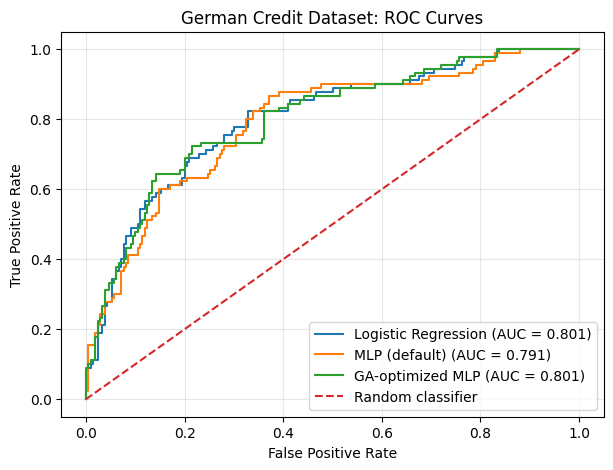

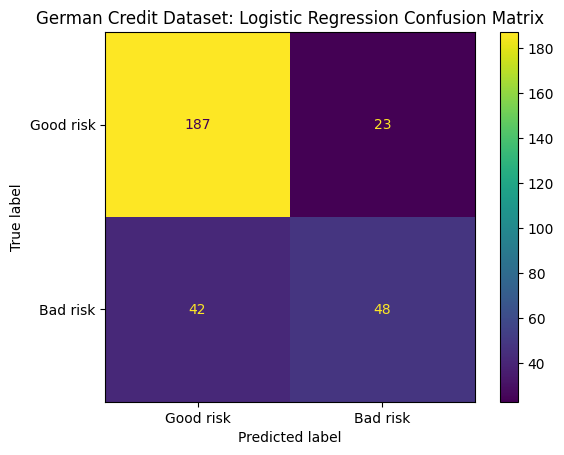

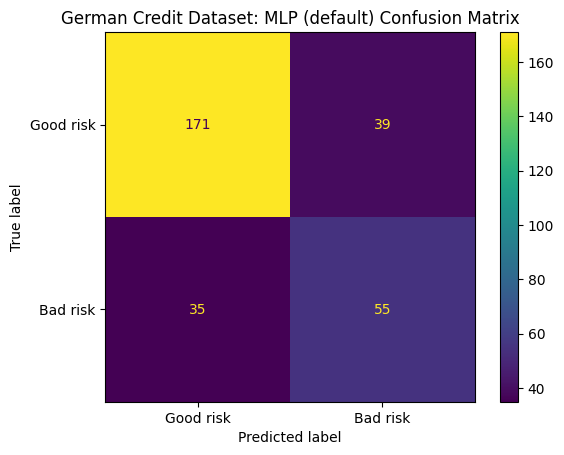

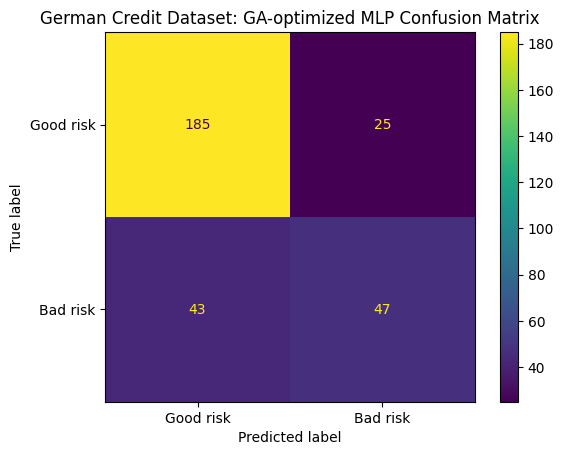

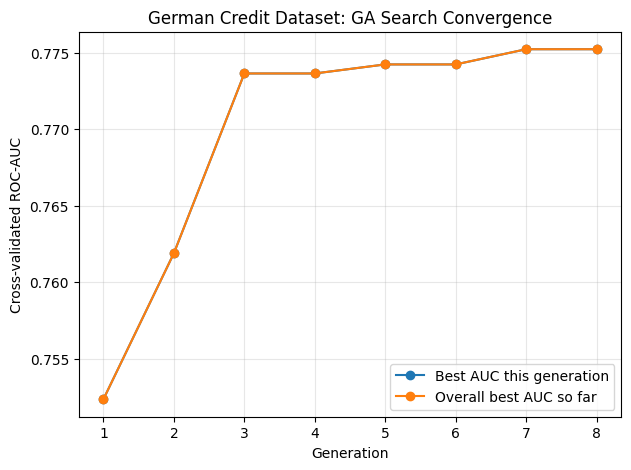

In [39]:
# Corrected German paper-grade plots using previously computed notebook predictions
# This avoids accidentally refitting a different "default" MLP architecture.

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

german_predictions_corrected = {
    "Logistic Regression": {
        "y_score": y_test_proba_lr,
        "y_pred": y_test_pred_lr
    },
    "MLP (default)": {
        "y_score": y_test_proba_mlp,
        "y_pred": y_test_pred_mlp
    },
    "GA-optimized MLP": {
        "y_score": y_test_proba_ga,
        "y_pred": y_test_pred_ga
    }
}

german_plot_results_corrected = []

for model_name, preds in german_predictions_corrected.items():
    german_plot_results_corrected.append({
        "model": model_name,
        "roc_auc": roc_auc_score(y_test, preds["y_score"]),
        "accuracy": accuracy_score(y_test, preds["y_pred"]),
        "precision": precision_score(y_test, preds["y_pred"]),
        "recall": recall_score(y_test, preds["y_pred"]),
        "f1": f1_score(y_test, preds["y_pred"])
    })

german_plot_results_corrected_df = pd.DataFrame(
    german_plot_results_corrected
).sort_values(
    by="roc_auc",
    ascending=False
)

print("CORRECTED GERMAN HELD-OUT TEST RESULTS FOR PAPER MODELS")
print("-" * 70)
print(german_plot_results_corrected_df.round(4).to_string(index=False))

# ROC curves
plt.figure(figsize=(7, 5))

for model_name, preds in german_predictions_corrected.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_score"])
    auc_value = roc_auc_score(y_test, preds["y_score"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("German Credit Dataset: ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Confusion matrices
for model_name, preds in german_predictions_corrected.items():
    cm = confusion_matrix(y_test, preds["y_pred"])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Good risk", "Bad risk"]
    )
    disp.plot(values_format="d")
    plt.title(f"German Credit Dataset: {model_name} Confusion Matrix")
    plt.show()

# GA convergence plot
plt.figure(figsize=(7, 5))

plt.plot(
    ga_full_history_df["generation"],
    ga_full_history_df["best_auc_this_generation"],
    marker="o",
    label="Best AUC this generation"
)

plt.plot(
    ga_full_history_df["generation"],
    ga_full_history_df["overall_best_auc_so_far"],
    marker="o",
    label="Overall best AUC so far"
)

plt.xlabel("Generation")
plt.ylabel("Cross-validated ROC-AUC")
plt.title("German Credit Dataset: GA Search Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### German Credit Dataset: Visual Results Interpretation

The corrected German held-out test results show that the GA-optimized MLP achieved the highest ROC-AUC, with a value of 0.8013. Logistic regression was almost identical, with ROC-AUC 0.8011. This means the GA-optimized MLP ranked good-risk and bad-risk applicants slightly better, but the difference is too small to interpret as a meaningful practical improvement.

Logistic regression performed slightly better on threshold-based metrics, including accuracy, precision, recall, and F1. The default MLP had lower ROC-AUC than both logistic regression and the GA-optimized MLP, but it produced the highest recall and F1 at the 0.50 threshold. This suggests that the default MLP classified more bad-risk applicants correctly, but at the cost of more false positives.

Overall, the German dataset supports the conclusion that GA-based architecture tuning improved the MLP's ROC-AUC relative to the default MLP. However, it does not provide strong evidence that the GA-optimized MLP meaningfully outperformed logistic regression on held-out data. Therefore, the German result should be described as competitive rather than clearly superior.

### German Credit Dataset: Exhaustive Search Sanity Check

The previous German GA search evaluated only a subset of the MLP architecture search space. This is consistent with the heuristic purpose of a genetic algorithm, but the related credit-scoring GA study also compares the GA-selected architecture against the global optimum within its defined architecture space.

To make the German analysis more rigorous, the next step exhaustively evaluates every MLP configuration in the same German search space used by the GA. This allows the GA-selected architecture to be ranked against the full grid of possible configurations and shows whether the GA found a globally best or near-best architecture.

In [47]:
# German Credit dataset: exhaustive grid-search sanity check
# Goal: compare the GA-selected German architecture against the full search space.

import itertools
import numpy as np
import pandas as pd

required_objects = [
    "search_space",
    "fitness_cache",
    "evaluate_mlp_config_cached",
    "config_to_key",
    "ga_best_config",
    "X_train",
    "y_train",
    "cv"
]

missing_objects = [obj for obj in required_objects if obj not in globals()]
if missing_objects:
    raise NameError(f"Missing required notebook objects: {missing_objects}")

german_grid_rows = []

all_german_configs = []

for hidden_layer_sizes, activation, alpha, learning_rate_init, batch_size in itertools.product(
    search_space["hidden_layer_sizes"],
    search_space["activation"],
    search_space["alpha"],
    search_space["learning_rate_init"],
    search_space["batch_size"]
):
    config = {
        "hidden_layer_sizes": hidden_layer_sizes,
        "activation": activation,
        "alpha": alpha,
        "learning_rate_init": learning_rate_init,
        "batch_size": batch_size
    }
    all_german_configs.append(config)

print("GERMAN EXHAUSTIVE GRID SEARCH")
print("-" * 70)
print("Total configurations to evaluate:", len(all_german_configs))
print("Already cached from GA search:", len(fitness_cache))

for i, config in enumerate(all_german_configs, start=1):
    result = evaluate_mlp_config_cached(config, X_train, y_train, cv)

    german_grid_rows.append({
        "config_key": config_to_key(config),
        "hidden_layer_sizes": config["hidden_layer_sizes"],
        "activation": config["activation"],
        "alpha": config["alpha"],
        "learning_rate_init": config["learning_rate_init"],
        "batch_size": config["batch_size"],
        "cv_roc_auc_mean": float(result["mean_auc"]),
        "cv_roc_auc_std": float(result["std_auc"])
    })

    if i % 50 == 0 or i == len(all_german_configs):
        print(f"Completed {i} / {len(all_german_configs)} configurations")

german_grid_results_df = pd.DataFrame(german_grid_rows).sort_values(
    by="cv_roc_auc_mean",
    ascending=False
).reset_index(drop=True)

german_grid_results_df["rank"] = np.arange(1, len(german_grid_results_df) + 1)

german_grid_best = german_grid_results_df.iloc[0]
german_ga_key = config_to_key(ga_best_config)

german_ga_grid_row = german_grid_results_df[
    german_grid_results_df["config_key"] == german_ga_key
].iloc[0]

german_ga_gap_from_grid_best = (
    german_grid_best["cv_roc_auc_mean"] - german_ga_grid_row["cv_roc_auc_mean"]
)

print("\nGRID SEARCH SUMMARY")
print("-" * 70)
print("Best grid-search CV ROC-AUC:", round(german_grid_best["cv_roc_auc_mean"], 4))
print("Best grid-search CV std:", round(german_grid_best["cv_roc_auc_std"], 4))
print("Best grid-search config:")
print({
    "hidden_layer_sizes": german_grid_best["hidden_layer_sizes"],
    "activation": german_grid_best["activation"],
    "alpha": german_grid_best["alpha"],
    "learning_rate_init": german_grid_best["learning_rate_init"],
    "batch_size": german_grid_best["batch_size"]
})

print("\nGA-SELECTED CONFIG RANK WITHIN FULL GRID")
print("-" * 70)
print("GA-selected CV ROC-AUC:", round(german_ga_grid_row["cv_roc_auc_mean"], 4))
print("GA-selected CV std:", round(german_ga_grid_row["cv_roc_auc_std"], 4))
print("GA-selected rank:", int(german_ga_grid_row["rank"]), "out of", len(german_grid_results_df))
print("Gap from grid-search best:", round(german_ga_gap_from_grid_best, 6))

print("\nNumber of configurations within 0.001 AUC of grid best:")
print((german_grid_best["cv_roc_auc_mean"] - german_grid_results_df["cv_roc_auc_mean"] <= 0.001).sum())

print("\nNumber of configurations within 0.005 AUC of grid best:")
print((german_grid_best["cv_roc_auc_mean"] - german_grid_results_df["cv_roc_auc_mean"] <= 0.005).sum())

print("\nTOP 10 GERMAN GRID-SEARCH CONFIGURATIONS")
print("-" * 70)
print(
    german_grid_results_df[
        [
            "rank",
            "cv_roc_auc_mean",
            "cv_roc_auc_std",
            "hidden_layer_sizes",
            "activation",
            "alpha",
            "learning_rate_init",
            "batch_size"
        ]
    ].head(10).round(4).to_string(index=False)
)

GERMAN EXHAUSTIVE GRID SEARCH
----------------------------------------------------------------------
Total configurations to evaluate: 1320
Already cached from GA search: 64
Completed 50 / 1320 configurations
Completed 100 / 1320 configurations
Completed 150 / 1320 configurations
Completed 200 / 1320 configurations
Completed 250 / 1320 configurations
Completed 300 / 1320 configurations
Completed 350 / 1320 configurations
Completed 400 / 1320 configurations
Completed 450 / 1320 configurations
Completed 500 / 1320 configurations
Completed 550 / 1320 configurations
Completed 600 / 1320 configurations
Completed 650 / 1320 configurations
Completed 700 / 1320 configurations
Completed 750 / 1320 configurations
Completed 800 / 1320 configurations
Completed 850 / 1320 configurations
Completed 900 / 1320 configurations
Completed 950 / 1320 configurations
Completed 1000 / 1320 configurations
Completed 1050 / 1320 configurations
Completed 1100 / 1320 configurations
Completed 1150 / 1320 configurat

### German Credit Dataset: Exhaustive Search Interpretation

The exhaustive German grid search evaluated all 1,320 MLP configurations in the same architecture search space used by the genetic algorithm. This provides a global reference point for judging the quality of the GA-selected architecture.

The best grid-search architecture achieved a mean cross-validated ROC-AUC of 0.7791. This model used one hidden layer with 8 units, `relu` activation, `alpha = 0.01`, `learning_rate_init = 0.0001`, and `batch_size = 32`.

The GA-selected architecture achieved a mean cross-validated ROC-AUC of 0.7752 and ranked 17th out of 1,320 configurations. Its gap from the grid-search best was 0.003845 ROC-AUC. Therefore, the GA did not find the global best architecture, but it found a near-best architecture while evaluating only 64 unique configurations, or about 4.85% of the full search space.

This result strengthens the German analysis. The appropriate conclusion is not that the GA found the absolute best MLP, but that it efficiently found a competitive near-optimal MLP architecture within the defined search space.

In [48]:
# German Credit dataset: evaluate grid-best MLP on held-out test set
# This compares the GA-selected MLP against the exhaustive grid-search best MLP.

import pandas as pd
import warnings

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.exceptions import ConvergenceWarning

def normalize_hidden_layer_sizes(value):
    if isinstance(value, tuple):
        return value
    if isinstance(value, list):
        return tuple(value)
    return (int(value),)

german_grid_best_config = {
    "hidden_layer_sizes": normalize_hidden_layer_sizes(german_grid_best["hidden_layer_sizes"]),
    "activation": str(german_grid_best["activation"]),
    "alpha": float(german_grid_best["alpha"]),
    "learning_rate_init": float(german_grid_best["learning_rate_init"]),
    "batch_size": int(german_grid_best["batch_size"])
}

selected_ga_config = ga_best_config if "ga_best_config" in globals() else overall_best["config"]

german_final_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ),
    "MLP (default)": MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ),
    "GA-optimized MLP": MLPClassifier(
        hidden_layer_sizes=selected_ga_config["hidden_layer_sizes"],
        activation=selected_ga_config["activation"],
        alpha=selected_ga_config["alpha"],
        learning_rate_init=selected_ga_config["learning_rate_init"],
        batch_size=selected_ga_config["batch_size"],
        solver="adam",
        max_iter=500,
        random_state=42
    ),
    "Grid-best MLP": MLPClassifier(
        hidden_layer_sizes=german_grid_best_config["hidden_layer_sizes"],
        activation=german_grid_best_config["activation"],
        alpha=german_grid_best_config["alpha"],
        learning_rate_init=german_grid_best_config["learning_rate_init"],
        batch_size=german_grid_best_config["batch_size"],
        solver="adam",
        max_iter=500,
        random_state=42
    )
}

german_final_rows = []
german_final_predictions = {}

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    for model_name, model in german_final_models.items():
        pipe = Pipeline(steps=[
            ("preprocess", preprocessor),
            ("model", model)
        ])

        pipe.fit(X_train, y_train)

        y_score = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_score >= 0.50).astype(int)

        german_final_predictions[model_name] = {
            "y_score": y_score,
            "y_pred": y_pred
        }

        german_final_rows.append({
            "dataset": "German",
            "model": model_name,
            "roc_auc": roc_auc_score(y_test, y_score),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred),
            "recall": recall_score(y_test, y_pred),
            "f1": f1_score(y_test, y_pred)
        })

german_final_results_df = pd.DataFrame(german_final_rows).sort_values(
    by="roc_auc",
    ascending=False
)

german_search_comparison_df = pd.DataFrame([
    {
        "model": "Grid-best MLP",
        "cv_roc_auc_mean": german_grid_best["cv_roc_auc_mean"],
        "cv_rank": int(german_grid_best["rank"]),
        "heldout_test_auc": german_final_results_df.loc[
            german_final_results_df["model"] == "Grid-best MLP", "roc_auc"
        ].iloc[0]
    },
    {
        "model": "GA-optimized MLP",
        "cv_roc_auc_mean": german_ga_grid_row["cv_roc_auc_mean"],
        "cv_rank": int(german_ga_grid_row["rank"]),
        "heldout_test_auc": german_final_results_df.loc[
            german_final_results_df["model"] == "GA-optimized MLP", "roc_auc"
        ].iloc[0]
    }
])

german_search_comparison_df["heldout_minus_cv_auc"] = (
    german_search_comparison_df["heldout_test_auc"]
    - german_search_comparison_df["cv_roc_auc_mean"]
)

print("GERMAN FINAL HELD-OUT TEST RESULTS INCLUDING GRID-BEST MLP")
print("-" * 80)
print(german_final_results_df.round(4).to_string(index=False))

print("\nGERMAN GA VS GRID-BEST SEARCH COMPARISON")
print("-" * 80)
print(german_search_comparison_df.round(4).to_string(index=False))

print("\nGERMAN GRID-BEST CONFIG")
print("-" * 80)
print(german_grid_best_config)

print("\nGERMAN GA-SELECTED CONFIG")
print("-" * 80)
print(selected_ga_config)

GERMAN FINAL HELD-OUT TEST RESULTS INCLUDING GRID-BEST MLP
--------------------------------------------------------------------------------
dataset               model  roc_auc  accuracy  precision  recall     f1
 German    GA-optimized MLP   0.8013    0.7733     0.6528  0.5222 0.5802
 German Logistic Regression   0.8011    0.7833     0.6761  0.5333 0.5963
 German       Grid-best MLP   0.7987    0.7600     0.6154  0.5333 0.5714
 German       MLP (default)   0.7908    0.7533     0.5851  0.6111 0.5978

GERMAN GA VS GRID-BEST SEARCH COMPARISON
--------------------------------------------------------------------------------
           model  cv_roc_auc_mean  cv_rank  heldout_test_auc  heldout_minus_cv_auc
   Grid-best MLP           0.7791        1            0.7987                0.0196
GA-optimized MLP           0.7752       17            0.8013                0.0260

GERMAN GRID-BEST CONFIG
--------------------------------------------------------------------------------
{'hidden_layer_si

### German Credit Dataset: Grid-Best Held-Out Test Interpretation

The exhaustive grid search identified a global CV-best MLP architecture with one hidden layer of 8 units, `relu` activation, `alpha = 0.01`, `learning_rate_init = 0.0001`, and `batch_size = 32`. This architecture achieved the highest mean cross-validated ROC-AUC within the defined German search space, with CV ROC-AUC 0.7791.

However, when evaluated on the held-out test set, the grid-best MLP achieved ROC-AUC 0.7987, which was slightly below the GA-optimized MLP's held-out ROC-AUC of 0.8013. The GA-selected model also remained the top held-out ROC-AUC model among the German models tested.

This shows that the CV-best architecture did not necessarily generalize best to the held-out test set. The GA-selected architecture did not find the global CV optimum, but it found a near-best architecture ranked 17 out of 1,320 and generalized slightly better than the grid-best architecture on the held-out test set.

Therefore, the German analysis should report both results: the exhaustive grid search as a global-search sanity check, and the GA-selected architecture as the final GA model. The main conclusion remains that GA tuning produced a competitive MLP and improved over the default MLP, but it did not meaningfully outperform logistic regression.

In [40]:
# Load and inspect Australian Credit dataset

import pandas as pd

australian_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/australian/australian.dat"

aus_cols = [f"A{i}" for i in range(1, 15)] + ["target"]

australian = pd.read_csv(
    australian_url,
    sep=r"\s+",
    header=None,
    names=aus_cols
)

# According to the Statlog Australian documentation:
# 6 continuous attributes: A2, A3, A7, A10, A13, A14
# 8 categorical attributes: A1, A4, A5, A6, A8, A9, A11, A12

aus_categorical_cols = ["A1", "A4", "A5", "A6", "A8", "A9", "A11", "A12"]
aus_numeric_cols = ["A2", "A3", "A7", "A10", "A13", "A14"]

# Create a project-consistent risk label.
# In this Statlog version, the target is usually coded 0/1.
# Prior credit-scoring literature often treats 1 as good and 0 as bad.
# Therefore: bad_risk = 1 means bad-risk applicant.
target_values = set(australian["target"].dropna().unique())

if target_values == {0, 1}:
    australian["bad_risk"] = (australian["target"] == 0).astype(int)
elif target_values == {1, 2}:
    australian["bad_risk"] = (australian["target"] == 2).astype(int)
else:
    raise ValueError(f"Unexpected Australian target values: {target_values}")

print("Shape:", australian.shape)
print("\nFirst 5 rows:")
print(australian.head())

print("\nOriginal target counts:")
print(australian["target"].value_counts().sort_index())

print("\nBad-risk counts:")
print(australian["bad_risk"].value_counts().sort_index())

print("\nBad-risk rate:")
print(australian["bad_risk"].mean())

print("\nMissing values:")
print(australian.isna().sum().sum())

print("\nCategorical columns:")
print(aus_categorical_cols)

print("\nNumeric columns:")
print(aus_numeric_cols)

print("\nUnique values per categorical feature:")
print(australian[aus_categorical_cols].nunique().sort_values())

print("\nNumeric feature summary:")
print(australian[aus_numeric_cols].describe().T)

Shape: (690, 16)

First 5 rows:
   A1     A2     A3  A4  A5  A6     A7  A8  A9  A10  A11  A12  A13   A14  \
0   1  22.08  11.46   2   4   4  1.585   0   0    0    1    2  100  1213   
1   0  22.67   7.00   2   8   4  0.165   0   0    0    0    2  160     1   
2   0  29.58   1.75   1   4   4  1.250   0   0    0    1    2  280     1   
3   0  21.67  11.50   1   5   3  0.000   1   1   11    1    2    0     1   
4   1  20.17   8.17   2   6   4  1.960   1   1   14    0    2   60   159   

   target  bad_risk  
0       0         1  
1       0         1  
2       0         1  
3       1         0  
4       1         0  

Original target counts:
target
0    383
1    307
Name: count, dtype: int64

Bad-risk counts:
bad_risk
0    307
1    383
Name: count, dtype: int64

Bad-risk rate:
0.5550724637681159

Missing values:
0

Categorical columns:
['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']

Numeric columns:
['A2', 'A3', 'A7', 'A10', 'A13', 'A14']

Unique values per categorical feature:
A1     

### Australian Credit Dataset: Initial Inspection Interpretation

The Australian credit dataset contains 690 observations. Unlike the German dataset, this benchmark is best interpreted as a credit approval dataset rather than a direct loan-default dataset. The original 0/1 target was recoded so that `bad_risk = 1` represents the adverse or negative credit-approval class. After recoding, there are 383 adverse-class applicants and 307 positive-class applicants, giving an adverse-class rate of about 55.5%.

The dataset contains no missing values. The predictors consist of 6 numeric variables and 8 categorical variables. Several categorical variables are binary, while the highest-cardinality categorical variable has 14 unique values. The numeric variables have different scales, especially `A14`, whose maximum value is much larger than its median, so scaling the numeric variables is appropriate before fitting logistic regression and MLP models.

This dataset is useful as a second benchmark because its class balance and feature structure differ from the German credit dataset. This allows the project to test whether the GA-selected MLP architecture is dataset-dependent.

In [41]:
# Australian Credit dataset: train/test split and preprocessing setup

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

X_aus = australian[aus_categorical_cols + aus_numeric_cols].copy()
y_aus = australian["bad_risk"].copy()

X_aus_train, X_aus_test, y_aus_train, y_aus_test = train_test_split(
    X_aus,
    y_aus,
    test_size=0.30,
    random_state=42,
    stratify=y_aus
)

try:
    aus_ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    aus_ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

aus_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), aus_numeric_cols),
        ("cat", aus_ohe, aus_categorical_cols)
    ],
    remainder="drop"
)

X_aus_train_processed = aus_preprocessor.fit_transform(X_aus_train)
X_aus_test_processed = aus_preprocessor.transform(X_aus_test)

print("AUSTRALIAN DATA / SPLIT AUDIT")
print("-" * 60)
print("Original Australian shape:", australian.shape)
print("Feature matrix shape:", X_aus.shape)
print("Target bad-risk counts:", y_aus.value_counts().sort_index().to_dict())
print("Training shape:", X_aus_train.shape)
print("Test shape:", X_aus_test.shape)
print("Training bad-risk rate:", round(y_aus_train.mean(), 4))
print("Test bad-risk rate:", round(y_aus_test.mean(), 4))
print("Processed training shape:", X_aus_train_processed.shape)
print("Processed test shape:", X_aus_test_processed.shape)

print("\nCategorical columns:")
print(aus_categorical_cols)

print("\nNumeric columns:")
print(aus_numeric_cols)

print("\nTraining target counts:")
print(y_aus_train.value_counts().sort_index())

print("\nTest target counts:")
print(y_aus_test.value_counts().sort_index())

AUSTRALIAN DATA / SPLIT AUDIT
------------------------------------------------------------
Original Australian shape: (690, 16)
Feature matrix shape: (690, 14)
Target bad-risk counts: {0: 307, 1: 383}
Training shape: (483, 14)
Test shape: (207, 14)
Training bad-risk rate: 0.5549
Test bad-risk rate: 0.5556
Processed training shape: (483, 42)
Processed test shape: (207, 42)

Categorical columns:
['A1', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12']

Numeric columns:
['A2', 'A3', 'A7', 'A10', 'A13', 'A14']

Training target counts:
bad_risk
0    215
1    268
Name: count, dtype: int64

Test target counts:
bad_risk
0     92
1    115
Name: count, dtype: int64


### Australian Credit Dataset: Split and Preprocessing Interpretation

The Australian credit dataset was split into a 70% training set and 30% held-out test set using stratification on the `bad_risk` target. This preserved the class balance across the two sets: the training bad-risk rate is 0.5549 and the test bad-risk rate is 0.5556.

The raw feature matrix contains 14 predictors: 6 numeric variables and 8 categorical variables. The preprocessing pipeline standardizes the numeric variables and one-hot encodes the categorical variables. This expands the feature space from 14 raw predictors to 42 processed predictors.

The preprocessing transformer was fit only on the training data and then applied to the test data, which avoids leakage from the held-out test set.

In [42]:
# Australian Credit dataset: baseline models

import warnings
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.exceptions import ConvergenceWarning

aus_baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ),
    "MLP (default)": MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    )
}

aus_results = []
aus_fitted_models = {}

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    for model_name, model in aus_baseline_models.items():
        pipe = Pipeline(steps=[
            ("preprocess", aus_preprocessor),
            ("model", model)
        ])

        pipe.fit(X_aus_train, y_aus_train)

        y_aus_test_proba = pipe.predict_proba(X_aus_test)[:, 1]
        y_aus_test_pred = (y_aus_test_proba >= 0.50).astype(int)

        aus_fitted_models[model_name] = pipe

        aus_results.append({
            "dataset": "Australian",
            "model": model_name,
            "roc_auc": roc_auc_score(y_aus_test, y_aus_test_proba),
            "accuracy": accuracy_score(y_aus_test, y_aus_test_pred),
            "precision": precision_score(y_aus_test, y_aus_test_pred),
            "recall": recall_score(y_aus_test, y_aus_test_pred),
            "f1": f1_score(y_aus_test, y_aus_test_pred)
        })

aus_results_df = pd.DataFrame(aus_results).sort_values(
    by="roc_auc",
    ascending=False
)

print("AUSTRALIAN BASELINE HELD-OUT TEST RESULTS")
print("-" * 60)
print(aus_results_df.round(4).to_string(index=False))

AUSTRALIAN BASELINE HELD-OUT TEST RESULTS
------------------------------------------------------------
   dataset               model  roc_auc  accuracy  precision  recall     f1
Australian Logistic Regression   0.9315    0.8599     0.9135  0.8261 0.8676
Australian       MLP (default)   0.9020    0.8551     0.8972  0.8348 0.8649


### Australian Credit Dataset: Baseline Model Interpretation

The Australian baseline results show strong held-out test performance. Logistic regression achieved ROC-AUC 0.9315, accuracy 0.8599, and F1 0.8676. The default MLP also performed well, with ROC-AUC 0.9020, accuracy 0.8551, and F1 0.8649.

At this stage, logistic regression is the stronger baseline on the Australian dataset. The default MLP is competitive in threshold-based metrics, but it ranks applicants less effectively according to ROC-AUC.

These results establish the benchmark for the GA-optimized MLP. To show useful architecture tuning, the GA-optimized MLP should improve over the default MLP's ROC-AUC of 0.9020. To support the stronger hypothesis that GA-optimized neural networks outperform logistic regression, it would need to approach or exceed logistic regression's ROC-AUC of 0.9315.

In [43]:
# Australian Credit dataset: baseline cross-validation

import numpy as np
import pandas as pd
import warnings

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.exceptions import ConvergenceWarning

aus_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

aus_cv_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ),
    "MLP (default)": MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    )
}

aus_cv_results = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    for model_name, model in aus_cv_models.items():
        pipe = Pipeline(steps=[
            ("preprocess", aus_preprocessor),
            ("model", model)
        ])

        fold_scores = cross_val_score(
            pipe,
            X_aus_train,
            y_aus_train,
            cv=aus_cv,
            scoring="roc_auc"
        )

        aus_cv_results.append({
            "model": model_name,
            "cv_roc_auc_mean": fold_scores.mean(),
            "cv_roc_auc_std": fold_scores.std(),
            "fold_1": fold_scores[0],
            "fold_2": fold_scores[1],
            "fold_3": fold_scores[2]
        })

aus_cv_results_df = pd.DataFrame(aus_cv_results).sort_values(
    by="cv_roc_auc_mean",
    ascending=False
)

print("AUSTRALIAN BASELINE 3-FOLD CV ROC-AUC")
print("-" * 60)
print(aus_cv_results_df.round(4).to_string(index=False))

AUSTRALIAN BASELINE 3-FOLD CV ROC-AUC
------------------------------------------------------------
              model  cv_roc_auc_mean  cv_roc_auc_std  fold_1  fold_2  fold_3
Logistic Regression           0.9263          0.0120  0.9269  0.9114  0.9407
      MLP (default)           0.9112          0.0139  0.9070  0.8965  0.9299


### Australian Credit Dataset: Baseline Cross-Validation Interpretation

The 3-fold cross-validation results confirm the held-out test pattern for the Australian dataset. Logistic regression achieved the stronger mean CV ROC-AUC of 0.9263, while the default MLP achieved a mean CV ROC-AUC of 0.9112.

The fold-level scores are reasonably stable for both models. Logistic regression ranges from 0.9114 to 0.9407 across folds, while the default MLP ranges from 0.8965 to 0.9299. This suggests that the Australian baseline comparison is not being driven by a single unusual split.

At this stage, logistic regression is the strongest Australian baseline. The GA-optimized MLP should first be evaluated against the default MLP to determine whether architecture search improves neural network performance, and then against logistic regression to test the stronger project hypothesis.

In [44]:
# Australian Credit dataset: Genetic Algorithm search for MLP architecture

import random
import numpy as np
import pandas as pd
import warnings

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.exceptions import ConvergenceWarning

random.seed(42)
np.random.seed(42)

aus_search_space = {
    "hidden_layer_sizes": [(8,), (16,), (32,), (64,), (16, 8), (32, 16), (64, 32)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.0001, 0.001, 0.01],
    "batch_size": [16, 32, 64]
}

aus_total_combinations = (
    len(aus_search_space["hidden_layer_sizes"])
    * len(aus_search_space["activation"])
    * len(aus_search_space["alpha"])
    * len(aus_search_space["learning_rate_init"])
    * len(aus_search_space["batch_size"])
)

def make_random_aus_config():
    return {
        key: random.choice(values)
        for key, values in aus_search_space.items()
    }

def aus_config_to_tuple(config):
    return (
        config["hidden_layer_sizes"],
        config["activation"],
        config["alpha"],
        config["learning_rate_init"],
        config["batch_size"]
    )

def evaluate_aus_config(config):
    config_key = aus_config_to_tuple(config)

    if config_key in aus_fitness_cache:
        return aus_fitness_cache[config_key]

    model = MLPClassifier(
        hidden_layer_sizes=config["hidden_layer_sizes"],
        activation=config["activation"],
        alpha=config["alpha"],
        learning_rate_init=config["learning_rate_init"],
        batch_size=config["batch_size"],
        solver="adam",
        max_iter=500,
        random_state=42
    )

    pipe = Pipeline(steps=[
        ("preprocess", aus_preprocessor),
        ("model", model)
    ])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)

        scores = cross_val_score(
            pipe,
            X_aus_train,
            y_aus_train,
            cv=aus_cv,
            scoring="roc_auc"
        )

    mean_score = scores.mean()
    aus_fitness_cache[config_key] = mean_score

    return mean_score

def crossover_aus_configs(parent_1, parent_2):
    child = {}

    for key in aus_search_space.keys():
        child[key] = random.choice([parent_1[key], parent_2[key]])

    return child

def mutate_aus_config(config, mutation_rate=0.25):
    mutated = config.copy()

    for key, values in aus_search_space.items():
        if random.random() < mutation_rate:
            mutated[key] = random.choice(values)

    return mutated

aus_population_size = 10
aus_generations = 8
aus_elite_size = 3
aus_mutation_rate = 0.25

aus_fitness_cache = {}
aus_population = [make_random_aus_config() for _ in range(aus_population_size)]
aus_ga_history = []

for generation in range(1, aus_generations + 1):
    scored_population = []

    for config in aus_population:
        score = evaluate_aus_config(config)
        scored_population.append({
            "generation": generation,
            "config": config,
            "cv_roc_auc": score
        })

    scored_population = sorted(
        scored_population,
        key=lambda x: x["cv_roc_auc"],
        reverse=True
    )

    best_this_generation = scored_population[0]

    if generation == 1:
        aus_overall_best = best_this_generation
    elif best_this_generation["cv_roc_auc"] > aus_overall_best["cv_roc_auc"]:
        aus_overall_best = best_this_generation

    aus_ga_history.append({
        "generation": generation,
        "best_auc_this_generation": best_this_generation["cv_roc_auc"],
        "overall_best_auc_so_far": aus_overall_best["cv_roc_auc"],
        "best_config_this_generation": best_this_generation["config"],
        "overall_best_config_so_far": aus_overall_best["config"]
    })

    elites = [item["config"] for item in scored_population[:aus_elite_size]]

    new_population = elites.copy()

    while len(new_population) < aus_population_size:
        parent_1, parent_2 = random.sample(elites, 2)
        child = crossover_aus_configs(parent_1, parent_2)
        child = mutate_aus_config(child, mutation_rate=aus_mutation_rate)
        new_population.append(child)

    aus_population = new_population

aus_ga_history_df = pd.DataFrame(aus_ga_history)
aus_ga_best_config = aus_overall_best["config"]
aus_ga_best_auc = aus_overall_best["cv_roc_auc"]

print("AUSTRALIAN GA SEARCH SUMMARY")
print("-" * 60)
print("Total possible GA configurations:", aus_total_combinations)
print("Unique configurations evaluated:", len(aus_fitness_cache))
print("Percent of search space evaluated:", f"{len(aus_fitness_cache) / aus_total_combinations:.2%}")
print("Best GA CV ROC-AUC:", round(aus_ga_best_auc, 4))
print("Best GA config:")
print(aus_ga_best_config)

print("\nAustralian GA convergence history:")
print(
    aus_ga_history_df[
        ["generation", "best_auc_this_generation", "overall_best_auc_so_far"]
    ].round(4).to_string(index=False)
)

AUSTRALIAN GA SEARCH SUMMARY
------------------------------------------------------------
Total possible GA configurations: 378
Unique configurations evaluated: 40
Percent of search space evaluated: 10.58%
Best GA CV ROC-AUC: 0.9306
Best GA config:
{'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 0.01, 'learning_rate_init': 0.0001, 'batch_size': 64}

Australian GA convergence history:
 generation  best_auc_this_generation  overall_best_auc_so_far
          1                    0.9274                   0.9274
          2                    0.9289                   0.9289
          3                    0.9303                   0.9303
          4                    0.9303                   0.9303
          5                    0.9303                   0.9303
          6                    0.9303                   0.9303
          7                    0.9306                   0.9306
          8                    0.9306                   0.9306


### Australian Credit Dataset: Genetic Algorithm Search Interpretation

The Australian GA search evaluated 40 unique MLP configurations out of 378 possible configurations, covering about 10.58% of the full search space. The best architecture found was a one-hidden-layer MLP with 64 hidden units, `relu` activation, `alpha = 0.01`, `learning_rate_init = 0.0001`, and `batch_size = 64`.

The best GA cross-validated ROC-AUC was 0.9306. This improves substantially over the default MLP baseline CV ROC-AUC of 0.9112 and slightly exceeds the logistic regression baseline CV ROC-AUC of 0.9263.

The convergence history shows that the GA improved from 0.9274 in generation 1 to 0.9306 by generation 7, then stabilized. This indicates that the GA search found a stronger MLP architecture without evaluating the full search space.

Compared with the German dataset, the selected Australian architecture is larger and uses a different activation function. This supports the secondary hypothesis that the preferred MLP architecture may be dataset-dependent. However, because the German and Australian experiments used different search-space sizes, this conclusion should be interpreted as suggestive rather than definitive.

In [45]:
# Australian Credit dataset: evaluate selected GA-optimized MLP on held-out test set

import pandas as pd
import warnings

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.exceptions import ConvergenceWarning

aus_ga_model = MLPClassifier(
    hidden_layer_sizes=aus_ga_best_config["hidden_layer_sizes"],
    activation=aus_ga_best_config["activation"],
    alpha=aus_ga_best_config["alpha"],
    learning_rate_init=aus_ga_best_config["learning_rate_init"],
    batch_size=aus_ga_best_config["batch_size"],
    solver="adam",
    max_iter=500,
    random_state=42
)

aus_ga_pipeline = Pipeline(steps=[
    ("preprocess", aus_preprocessor),
    ("model", aus_ga_model)
])

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)
    aus_ga_pipeline.fit(X_aus_train, y_aus_train)

y_aus_test_proba_ga = aus_ga_pipeline.predict_proba(X_aus_test)[:, 1]
y_aus_test_pred_ga = (y_aus_test_proba_ga >= 0.50).astype(int)

aus_ga_result = pd.DataFrame([{
    "dataset": "Australian",
    "model": "GA-optimized MLP",
    "roc_auc": roc_auc_score(y_aus_test, y_aus_test_proba_ga),
    "accuracy": accuracy_score(y_aus_test, y_aus_test_pred_ga),
    "precision": precision_score(y_aus_test, y_aus_test_pred_ga),
    "recall": recall_score(y_aus_test, y_aus_test_pred_ga),
    "f1": f1_score(y_aus_test, y_aus_test_pred_ga)
}])

aus_results_with_ga_df = pd.concat(
    [aus_results_df, aus_ga_result],
    ignore_index=True
).sort_values(
    by="roc_auc",
    ascending=False
)

print("AUSTRALIAN HELD-OUT TEST RESULTS WITH GA")
print("-" * 60)
print(aus_results_with_ga_df.round(4).to_string(index=False))

print("\nSELECTED AUSTRALIAN GA CONFIG")
print("-" * 60)
print(aus_ga_best_config)

AUSTRALIAN HELD-OUT TEST RESULTS WITH GA
------------------------------------------------------------
   dataset               model  roc_auc  accuracy  precision  recall     f1
Australian Logistic Regression   0.9315    0.8599     0.9135  0.8261 0.8676
Australian    GA-optimized MLP   0.9241    0.8599     0.8981  0.8435 0.8700
Australian       MLP (default)   0.9020    0.8551     0.8972  0.8348 0.8649

SELECTED AUSTRALIAN GA CONFIG
------------------------------------------------------------
{'hidden_layer_sizes': (64,), 'activation': 'relu', 'alpha': 0.01, 'learning_rate_init': 0.0001, 'batch_size': 64}


### Australian Credit Dataset: GA Held-Out Test Interpretation

On the Australian held-out test set, logistic regression achieved the highest ROC-AUC, with a value of 0.9315. The GA-optimized MLP achieved ROC-AUC 0.9241, while the default MLP achieved ROC-AUC 0.9020.

The GA-optimized MLP therefore improved substantially over the default MLP in ROC-AUC, supporting the idea that architecture tuning improves neural network performance. However, it did not outperform logistic regression on held-out ROC-AUC.

The threshold-based metrics show a slightly different pattern. The GA-optimized MLP achieved the highest F1 score, 0.8700, due to its higher recall compared with logistic regression. This suggests that at the default 0.50 threshold, the GA model identified more bad-risk applicants while maintaining strong precision.

Overall, the Australian results support the narrower claim that GA-based architecture search improves MLP performance relative to default MLP settings. They do not fully support the stronger claim that GA-optimized MLPs consistently outperform logistic regression.

In [46]:
# Australian Credit dataset: actual fold-level CV scores for selected GA model

import numpy as np
import pandas as pd
import warnings

from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score
from sklearn.exceptions import ConvergenceWarning

aus_selected_ga_pipeline = Pipeline(steps=[
    ("preprocess", aus_preprocessor),
    ("model", MLPClassifier(
        hidden_layer_sizes=aus_ga_best_config["hidden_layer_sizes"],
        activation=aus_ga_best_config["activation"],
        alpha=aus_ga_best_config["alpha"],
        learning_rate_init=aus_ga_best_config["learning_rate_init"],
        batch_size=aus_ga_best_config["batch_size"],
        solver="adam",
        max_iter=500,
        random_state=42
    ))
])

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    aus_selected_ga_fold_scores = cross_val_score(
        aus_selected_ga_pipeline,
        X_aus_train,
        y_aus_train,
        cv=aus_cv,
        scoring="roc_auc"
    )

aus_ga_cv_actual = pd.DataFrame([{
    "model": "GA-optimized MLP",
    "cv_roc_auc_mean": aus_selected_ga_fold_scores.mean(),
    "cv_roc_auc_std": aus_selected_ga_fold_scores.std(),
    "fold_1": aus_selected_ga_fold_scores[0],
    "fold_2": aus_selected_ga_fold_scores[1],
    "fold_3": aus_selected_ga_fold_scores[2]
}])

aus_cv_summary_actual = pd.concat(
    [aus_cv_results_df, aus_ga_cv_actual],
    ignore_index=True
).sort_values(
    by="cv_roc_auc_mean",
    ascending=False
)

print("AUSTRALIAN SELECTED GA FOLD-LEVEL CV ROC-AUC")
print("-" * 70)
print("Fold scores:", np.round(aus_selected_ga_fold_scores, 4))
print("Mean:", round(aus_selected_ga_fold_scores.mean(), 4))
print("Std:", round(aus_selected_ga_fold_scores.std(), 4))

print("\nAUSTRALIAN CV SUMMARY WITH ACTUAL GA FOLDS")
print("-" * 70)
print(aus_cv_summary_actual.round(4).to_string(index=False))

print("\nAUSTRALIAN CV VS HELD-OUT TEST AUC")
print("-" * 70)

aus_cv_vs_test = pd.merge(
    aus_cv_summary_actual[["model", "cv_roc_auc_mean"]],
    aus_results_with_ga_df[["model", "roc_auc"]],
    on="model",
    how="inner"
).rename(columns={"roc_auc": "heldout_test_auc"})

aus_cv_vs_test["test_minus_cv_auc"] = (
    aus_cv_vs_test["heldout_test_auc"] - aus_cv_vs_test["cv_roc_auc_mean"]
)

print(aus_cv_vs_test.round(4).to_string(index=False))

AUSTRALIAN SELECTED GA FOLD-LEVEL CV ROC-AUC
----------------------------------------------------------------------
Fold scores: [0.926  0.9182 0.9476]
Mean: 0.9306
Std: 0.0124

AUSTRALIAN CV SUMMARY WITH ACTUAL GA FOLDS
----------------------------------------------------------------------
              model  cv_roc_auc_mean  cv_roc_auc_std  fold_1  fold_2  fold_3
   GA-optimized MLP           0.9306          0.0124  0.9260  0.9182  0.9476
Logistic Regression           0.9263          0.0120  0.9269  0.9114  0.9407
      MLP (default)           0.9112          0.0139  0.9070  0.8965  0.9299

AUSTRALIAN CV VS HELD-OUT TEST AUC
----------------------------------------------------------------------
              model  cv_roc_auc_mean  heldout_test_auc  test_minus_cv_auc
   GA-optimized MLP           0.9306            0.9241            -0.0065
Logistic Regression           0.9263            0.9315             0.0051
      MLP (default)           0.9112            0.9020            -0.00

### Australian Credit Dataset: GA Cross-Validation and Generalization Interpretation

The selected Australian GA-optimized MLP achieved fold-level ROC-AUC scores of 0.9260, 0.9182, and 0.9476, giving a mean cross-validated ROC-AUC of 0.9306. This was higher than both logistic regression, with mean CV ROC-AUC 0.9263, and the default MLP, with mean CV ROC-AUC 0.9112.

However, the held-out test set showed a slightly different ordering. Logistic regression achieved the highest held-out ROC-AUC of 0.9315, while the GA-optimized MLP achieved 0.9241. The default MLP remained lower at 0.9020.

This means the Australian dataset provides strong evidence that GA tuning improved the MLP relative to default MLP settings. It also shows that the GA-optimized MLP was competitive with logistic regression, but it did not outperform logistic regression on the held-out test ROC-AUC.

Because the GA evaluated only 40 unique configurations out of 378 possible configurations, the next step is to compare the selected GA architecture against a full grid search. This will show whether the GA found a globally best or near-best architecture within the defined search space.

In [49]:
# Australian Credit dataset: exhaustive grid-search sanity check
# Goal: determine whether the GA-selected architecture is globally best or near-best
# within the same search space used by the GA.

import itertools
import numpy as np
import pandas as pd

aus_grid_rows = []

all_aus_configs = []

for hidden_layer_sizes, activation, alpha, learning_rate_init, batch_size in itertools.product(
    aus_search_space["hidden_layer_sizes"],
    aus_search_space["activation"],
    aus_search_space["alpha"],
    aus_search_space["learning_rate_init"],
    aus_search_space["batch_size"]
):
    config = {
        "hidden_layer_sizes": hidden_layer_sizes,
        "activation": activation,
        "alpha": alpha,
        "learning_rate_init": learning_rate_init,
        "batch_size": batch_size
    }
    all_aus_configs.append(config)

print("AUSTRALIAN EXHAUSTIVE GRID SEARCH")
print("-" * 70)
print("Total configurations to evaluate:", len(all_aus_configs))
print("Already cached from GA search:", len(aus_fitness_cache))

for i, config in enumerate(all_aus_configs, start=1):
    score = evaluate_aus_config(config)

    aus_grid_rows.append({
        "config_key": aus_config_to_tuple(config),
        "hidden_layer_sizes": config["hidden_layer_sizes"],
        "activation": config["activation"],
        "alpha": config["alpha"],
        "learning_rate_init": config["learning_rate_init"],
        "batch_size": config["batch_size"],
        "cv_roc_auc": score
    })

    if i % 50 == 0 or i == len(all_aus_configs):
        print(f"Completed {i} / {len(all_aus_configs)} configurations")

aus_grid_results_df = pd.DataFrame(aus_grid_rows).sort_values(
    by="cv_roc_auc",
    ascending=False
).reset_index(drop=True)

aus_grid_results_df["rank"] = np.arange(1, len(aus_grid_results_df) + 1)

aus_grid_best = aus_grid_results_df.iloc[0]
aus_ga_key = aus_config_to_tuple(aus_ga_best_config)
aus_ga_grid_row = aus_grid_results_df[
    aus_grid_results_df["config_key"] == aus_ga_key
].iloc[0]

aus_ga_gap_from_grid_best = aus_grid_best["cv_roc_auc"] - aus_ga_grid_row["cv_roc_auc"]

print("\nGRID SEARCH SUMMARY")
print("-" * 70)
print("Best grid-search CV ROC-AUC:", round(aus_grid_best["cv_roc_auc"], 4))
print("Best grid-search config:")
print({
    "hidden_layer_sizes": aus_grid_best["hidden_layer_sizes"],
    "activation": aus_grid_best["activation"],
    "alpha": aus_grid_best["alpha"],
    "learning_rate_init": aus_grid_best["learning_rate_init"],
    "batch_size": aus_grid_best["batch_size"]
})

print("\nGA-SELECTED CONFIG RANK WITHIN FULL GRID")
print("-" * 70)
print("GA-selected CV ROC-AUC:", round(aus_ga_grid_row["cv_roc_auc"], 4))
print("GA-selected rank:", int(aus_ga_grid_row["rank"]), "out of", len(aus_grid_results_df))
print("Gap from grid-search best:", round(aus_ga_gap_from_grid_best, 6))

print("\nNumber of configurations within 0.001 AUC of grid best:")
print((aus_grid_best["cv_roc_auc"] - aus_grid_results_df["cv_roc_auc"] <= 0.001).sum())

print("\nNumber of configurations within 0.005 AUC of grid best:")
print((aus_grid_best["cv_roc_auc"] - aus_grid_results_df["cv_roc_auc"] <= 0.005).sum())

print("\nTOP 10 AUSTRALIAN GRID-SEARCH CONFIGURATIONS")
print("-" * 70)
print(
    aus_grid_results_df[
        ["rank", "cv_roc_auc", "hidden_layer_sizes", "activation", "alpha", "learning_rate_init", "batch_size"]
    ].head(10).round(4).to_string(index=False)
)

AUSTRALIAN EXHAUSTIVE GRID SEARCH
----------------------------------------------------------------------
Total configurations to evaluate: 378
Already cached from GA search: 40
Completed 50 / 378 configurations
Completed 100 / 378 configurations
Completed 150 / 378 configurations
Completed 200 / 378 configurations
Completed 250 / 378 configurations
Completed 300 / 378 configurations
Completed 350 / 378 configurations
Completed 378 / 378 configurations

GRID SEARCH SUMMARY
----------------------------------------------------------------------
Best grid-search CV ROC-AUC: 0.9311
Best grid-search config:
{'hidden_layer_sizes': (32, 16), 'activation': 'tanh', 'alpha': np.float64(0.0001), 'learning_rate_init': np.float64(0.0001), 'batch_size': np.int64(64)}

GA-SELECTED CONFIG RANK WITHIN FULL GRID
----------------------------------------------------------------------
GA-selected CV ROC-AUC: 0.9306
GA-selected rank: 6 out of 378
Gap from grid-search best: 0.000523

Number of configurations 

### Australian Credit Dataset: Exhaustive Search Interpretation

The exhaustive Australian grid search evaluated all 378 MLP configurations in the same architecture search space used by the genetic algorithm. This provides a global reference point for evaluating the GA-selected architecture.

The best grid-search architecture achieved a mean cross-validated ROC-AUC of 0.9311. This model used hidden layers `(32, 16)`, `tanh` activation, `alpha = 0.0001`, `learning_rate_init = 0.0001`, and `batch_size = 64`.

The GA-selected architecture achieved a mean cross-validated ROC-AUC of 0.9306 and ranked 6th out of 378 configurations. Its gap from the grid-search best was only 0.000523 ROC-AUC. Therefore, the GA did not find the exact global best architecture, but it found a near-best architecture while evaluating only 40 unique configurations, or about 10.58% of the full search space.

This strengthens the Australian analysis. The GA was much more efficient than exhaustive search and still identified an architecture close to the global optimum within the defined search space.

In [50]:
# Australian Credit dataset: evaluate grid-best MLP on held-out test set
# This compares the GA-selected MLP against the exhaustive grid-search best MLP.

import pandas as pd
import warnings

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.exceptions import ConvergenceWarning

def normalize_hidden_layer_sizes(value):
    if isinstance(value, tuple):
        return value
    if isinstance(value, list):
        return tuple(value)
    return (int(value),)

aus_grid_best_config = {
    "hidden_layer_sizes": normalize_hidden_layer_sizes(aus_grid_best["hidden_layer_sizes"]),
    "activation": str(aus_grid_best["activation"]),
    "alpha": float(aus_grid_best["alpha"]),
    "learning_rate_init": float(aus_grid_best["learning_rate_init"]),
    "batch_size": int(aus_grid_best["batch_size"])
}

aus_final_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        random_state=42
    ),
    "MLP (default)": MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        solver="adam",
        max_iter=500,
        random_state=42
    ),
    "GA-optimized MLP": MLPClassifier(
        hidden_layer_sizes=aus_ga_best_config["hidden_layer_sizes"],
        activation=aus_ga_best_config["activation"],
        alpha=aus_ga_best_config["alpha"],
        learning_rate_init=aus_ga_best_config["learning_rate_init"],
        batch_size=aus_ga_best_config["batch_size"],
        solver="adam",
        max_iter=500,
        random_state=42
    ),
    "Grid-best MLP": MLPClassifier(
        hidden_layer_sizes=aus_grid_best_config["hidden_layer_sizes"],
        activation=aus_grid_best_config["activation"],
        alpha=aus_grid_best_config["alpha"],
        learning_rate_init=aus_grid_best_config["learning_rate_init"],
        batch_size=aus_grid_best_config["batch_size"],
        solver="adam",
        max_iter=500,
        random_state=42
    )
}

aus_final_rows = []
aus_final_predictions = {}

with warnings.catch_warnings():
    warnings.simplefilter("ignore", ConvergenceWarning)

    for model_name, model in aus_final_models.items():
        pipe = Pipeline(steps=[
            ("preprocess", aus_preprocessor),
            ("model", model)
        ])

        pipe.fit(X_aus_train, y_aus_train)

        y_score = pipe.predict_proba(X_aus_test)[:, 1]
        y_pred = (y_score >= 0.50).astype(int)

        aus_final_predictions[model_name] = {
            "y_score": y_score,
            "y_pred": y_pred
        }

        aus_final_rows.append({
            "dataset": "Australian",
            "model": model_name,
            "roc_auc": roc_auc_score(y_aus_test, y_score),
            "accuracy": accuracy_score(y_aus_test, y_pred),
            "precision": precision_score(y_aus_test, y_pred),
            "recall": recall_score(y_aus_test, y_pred),
            "f1": f1_score(y_aus_test, y_pred)
        })

aus_final_results_df = pd.DataFrame(aus_final_rows).sort_values(
    by="roc_auc",
    ascending=False
)

aus_search_comparison_df = pd.DataFrame([
    {
        "model": "Grid-best MLP",
        "cv_roc_auc_mean": aus_grid_best["cv_roc_auc"],
        "cv_rank": int(aus_grid_best["rank"]),
        "heldout_test_auc": aus_final_results_df.loc[
            aus_final_results_df["model"] == "Grid-best MLP", "roc_auc"
        ].iloc[0]
    },
    {
        "model": "GA-optimized MLP",
        "cv_roc_auc_mean": aus_ga_grid_row["cv_roc_auc"],
        "cv_rank": int(aus_ga_grid_row["rank"]),
        "heldout_test_auc": aus_final_results_df.loc[
            aus_final_results_df["model"] == "GA-optimized MLP", "roc_auc"
        ].iloc[0]
    }
])

aus_search_comparison_df["heldout_minus_cv_auc"] = (
    aus_search_comparison_df["heldout_test_auc"]
    - aus_search_comparison_df["cv_roc_auc_mean"]
)

print("AUSTRALIAN FINAL HELD-OUT TEST RESULTS INCLUDING GRID-BEST MLP")
print("-" * 80)
print(aus_final_results_df.round(4).to_string(index=False))

print("\nAUSTRALIAN GA VS GRID-BEST SEARCH COMPARISON")
print("-" * 80)
print(aus_search_comparison_df.round(4).to_string(index=False))

print("\nAUSTRALIAN GRID-BEST CONFIG")
print("-" * 80)
print(aus_grid_best_config)

print("\nAUSTRALIAN GA-SELECTED CONFIG")
print("-" * 80)
print(aus_ga_best_config)

AUSTRALIAN FINAL HELD-OUT TEST RESULTS INCLUDING GRID-BEST MLP
--------------------------------------------------------------------------------
   dataset               model  roc_auc  accuracy  precision  recall     f1
Australian Logistic Regression   0.9315    0.8599     0.9135  0.8261 0.8676
Australian       Grid-best MLP   0.9265    0.8599     0.9135  0.8261 0.8676
Australian    GA-optimized MLP   0.9241    0.8599     0.8981  0.8435 0.8700
Australian       MLP (default)   0.9020    0.8551     0.8972  0.8348 0.8649

AUSTRALIAN GA VS GRID-BEST SEARCH COMPARISON
--------------------------------------------------------------------------------
           model  cv_roc_auc_mean  cv_rank  heldout_test_auc  heldout_minus_cv_auc
   Grid-best MLP           0.9311        1            0.9265               -0.0046
GA-optimized MLP           0.9306        6            0.9241               -0.0065

AUSTRALIAN GRID-BEST CONFIG
-----------------------------------------------------------------------

### Australian Credit Dataset: Grid-Best Held-Out Test Interpretation

The exhaustive Australian grid search identified a global CV-best MLP architecture with hidden layers `(32, 16)`, `tanh` activation, `alpha = 0.0001`, `learning_rate_init = 0.0001`, and `batch_size = 64`. This architecture achieved the highest mean cross-validated ROC-AUC within the defined Australian search space, with CV ROC-AUC 0.9311.

On the held-out test set, the grid-best MLP achieved ROC-AUC 0.9265. This was slightly higher than the GA-optimized MLP's held-out ROC-AUC of 0.9241, but still below logistic regression's held-out ROC-AUC of 0.9315.

The GA-selected architecture ranked 6th out of 378 configurations and was only 0.000523 ROC-AUC below the grid-search best in cross-validation. Therefore, the GA did not find the exact global CV optimum, but it found a near-best architecture while evaluating only 40 unique configurations, or about 10.58% of the full search space.

Overall, the Australian results show that GA-based architecture tuning substantially improved the MLP relative to the default MLP. However, logistic regression remained the strongest held-out ROC-AUC model on this dataset.

In [51]:
# Final combined held-out test summary for both datasets

combined_final_results_df = pd.concat(
    [
        german_final_results_df,
        aus_final_results_df
    ],
    ignore_index=True
).sort_values(
    by=["dataset", "roc_auc"],
    ascending=[True, False]
)

print("FINAL HELD-OUT TEST SUMMARY ACROSS DATASETS")
print("-" * 90)
print(combined_final_results_df.round(4).to_string(index=False))

# Compact architecture comparison
architecture_summary_df = pd.DataFrame([
    {
        "dataset": "German",
        "method": "GA-selected MLP",
        "cv_rank": int(german_ga_grid_row["rank"]),
        "total_configs": len(german_grid_results_df),
        "cv_roc_auc": german_ga_grid_row["cv_roc_auc_mean"],
        "heldout_test_auc": german_final_results_df.loc[
            german_final_results_df["model"] == "GA-optimized MLP", "roc_auc"
        ].iloc[0],
        "config": str(selected_ga_config)
    },
    {
        "dataset": "German",
        "method": "Grid-best MLP",
        "cv_rank": 1,
        "total_configs": len(german_grid_results_df),
        "cv_roc_auc": german_grid_best["cv_roc_auc_mean"],
        "heldout_test_auc": german_final_results_df.loc[
            german_final_results_df["model"] == "Grid-best MLP", "roc_auc"
        ].iloc[0],
        "config": str(german_grid_best_config)
    },
    {
        "dataset": "Australian",
        "method": "GA-selected MLP",
        "cv_rank": int(aus_ga_grid_row["rank"]),
        "total_configs": len(aus_grid_results_df),
        "cv_roc_auc": aus_ga_grid_row["cv_roc_auc"],
        "heldout_test_auc": aus_final_results_df.loc[
            aus_final_results_df["model"] == "GA-optimized MLP", "roc_auc"
        ].iloc[0],
        "config": str(aus_ga_best_config)
    },
    {
        "dataset": "Australian",
        "method": "Grid-best MLP",
        "cv_rank": 1,
        "total_configs": len(aus_grid_results_df),
        "cv_roc_auc": aus_grid_best["cv_roc_auc"],
        "heldout_test_auc": aus_final_results_df.loc[
            aus_final_results_df["model"] == "Grid-best MLP", "roc_auc"
        ].iloc[0],
        "config": str(aus_grid_best_config)
    }
])

print("\nFINAL GA VS GRID-BEST ARCHITECTURE SUMMARY")
print("-" * 90)
print(
    architecture_summary_df[
        ["dataset", "method", "cv_rank", "total_configs", "cv_roc_auc", "heldout_test_auc", "config"]
    ].round(4).to_string(index=False)
)

FINAL HELD-OUT TEST SUMMARY ACROSS DATASETS
------------------------------------------------------------------------------------------
   dataset               model  roc_auc  accuracy  precision  recall     f1
Australian Logistic Regression   0.9315    0.8599     0.9135  0.8261 0.8676
Australian       Grid-best MLP   0.9265    0.8599     0.9135  0.8261 0.8676
Australian    GA-optimized MLP   0.9241    0.8599     0.8981  0.8435 0.8700
Australian       MLP (default)   0.9020    0.8551     0.8972  0.8348 0.8649
    German    GA-optimized MLP   0.8013    0.7733     0.6528  0.5222 0.5802
    German Logistic Regression   0.8011    0.7833     0.6761  0.5333 0.5963
    German       Grid-best MLP   0.7987    0.7600     0.6154  0.5333 0.5714
    German       MLP (default)   0.7908    0.7533     0.5851  0.6111 0.5978

FINAL GA VS GRID-BEST ARCHITECTURE SUMMARY
------------------------------------------------------------------------------------------
   dataset          method  cv_rank  total_con

### Final Cross-Dataset Results Interpretation

The final held-out test results show that the GA-optimized MLP improved over the default MLP on both datasets in ROC-AUC. On the German dataset, the GA-optimized MLP achieved ROC-AUC 0.8013 compared with 0.7908 for the default MLP. On the Australian dataset, the GA-optimized MLP achieved ROC-AUC 0.9241 compared with 0.9020 for the default MLP.

However, the stronger hypothesis that the GA-optimized MLP consistently outperforms logistic regression is not fully supported. On the German dataset, the GA-optimized MLP and logistic regression were essentially tied, with ROC-AUC values of 0.8013 and 0.8011. On the Australian dataset, logistic regression achieved the highest held-out ROC-AUC, with a value of 0.9315.

The exhaustive grid-search comparison provides an important sanity check. On German, the GA-selected MLP ranked 17th out of 1,320 configurations and was only 0.003845 CV ROC-AUC below the grid-best model. On Australian, the GA-selected MLP ranked 6th out of 378 configurations and was only 0.000523 CV ROC-AUC below the grid-best model.

Therefore, the main conclusion is that GA-based architecture search was effective at finding near-optimal MLP architectures while evaluating only a fraction of the full search space. The results support the narrower claim that GA tuning improves MLP performance relative to default settings, but they do not show consistent superiority over logistic regression.

The selected architectures also differed across datasets: German selected a smaller one-hidden-layer architecture, while Australian selected a larger architecture. This is consistent with the secondary hypothesis that the preferred architecture is dataset-dependent. However, because the exact search spaces were not identical across datasets, the result should be described cautiously as evidence suggesting dataset dependence rather than a definitive proof.

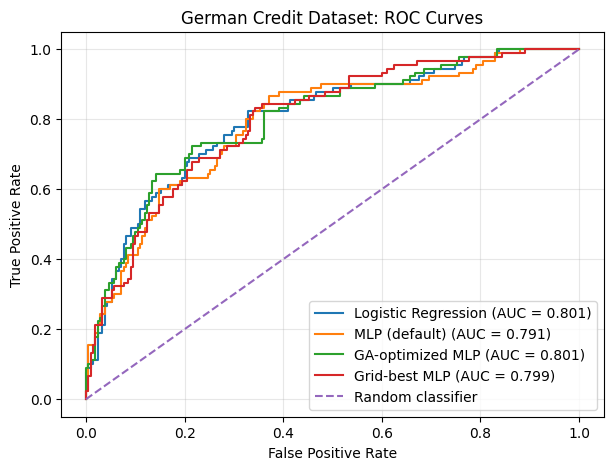

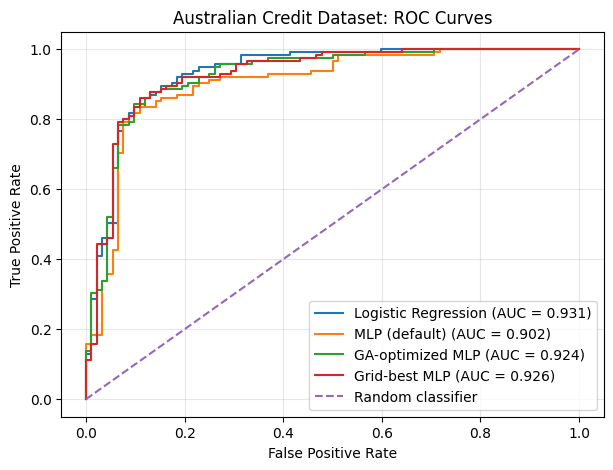

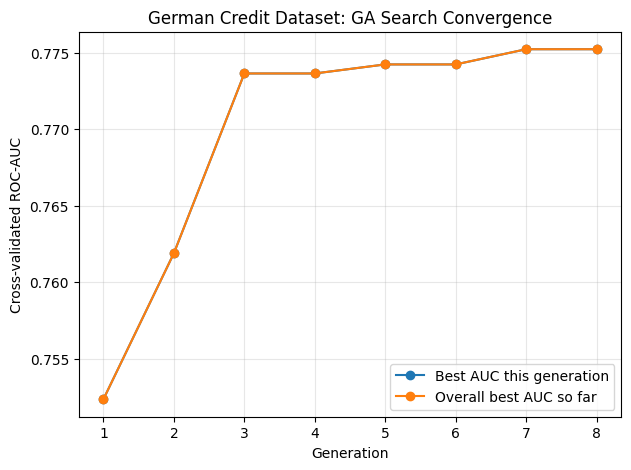

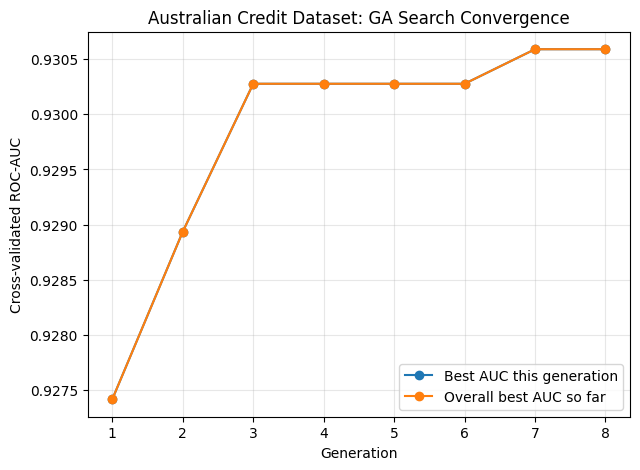

In [52]:
# Final paper visuals: ROC curves and GA convergence for both datasets

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# German ROC curves
plt.figure(figsize=(7, 5))

for model_name, preds in german_final_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, preds["y_score"])
    auc_value = roc_auc_score(y_test, preds["y_score"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("German Credit Dataset: ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Australian ROC curves
plt.figure(figsize=(7, 5))

for model_name, preds in aus_final_predictions.items():
    fpr, tpr, _ = roc_curve(y_aus_test, preds["y_score"])
    auc_value = roc_auc_score(y_aus_test, preds["y_score"])
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_value:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Australian Credit Dataset: ROC Curves")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# German GA convergence
plt.figure(figsize=(7, 5))

plt.plot(
    ga_full_history_df["generation"],
    ga_full_history_df["best_auc_this_generation"],
    marker="o",
    label="Best AUC this generation"
)

plt.plot(
    ga_full_history_df["generation"],
    ga_full_history_df["overall_best_auc_so_far"],
    marker="o",
    label="Overall best AUC so far"
)

plt.xlabel("Generation")
plt.ylabel("Cross-validated ROC-AUC")
plt.title("German Credit Dataset: GA Search Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Australian GA convergence
plt.figure(figsize=(7, 5))

plt.plot(
    aus_ga_history_df["generation"],
    aus_ga_history_df["best_auc_this_generation"],
    marker="o",
    label="Best AUC this generation"
)

plt.plot(
    aus_ga_history_df["generation"],
    aus_ga_history_df["overall_best_auc_so_far"],
    marker="o",
    label="Overall best AUC so far"
)

plt.xlabel("Generation")
plt.ylabel("Cross-validated ROC-AUC")
plt.title("Australian Credit Dataset: GA Search Convergence")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Final Visual Results Interpretation

The ROC curves summarize the held-out ranking performance of each model. On the German dataset, the GA-optimized MLP, logistic regression, and grid-best MLP perform very similarly, while the default MLP is slightly weaker. The GA-optimized MLP has the highest held-out ROC-AUC, but the difference from logistic regression is extremely small.

On the Australian dataset, all models perform better than on German. Logistic regression achieves the highest held-out ROC-AUC, followed by the grid-best MLP, the GA-optimized MLP, and the default MLP. The GA-optimized MLP clearly improves over the default MLP, but it does not exceed logistic regression.

The GA convergence plots show that both searches improved during the early generations and then stabilized. This supports the interpretation that the GA search was not random trial-and-error, but an evolutionary search process that moved toward stronger architectures. However, the exhaustive grid-search comparison showed that the GA found near-best architectures rather than the exact global CV-best architectures.

Overall, the visual results support the main conclusion: genetic algorithms are effective for finding competitive MLP architectures with far fewer evaluations than exhaustive search, but the GA-optimized MLP does not consistently outperform logistic regression on these benchmark credit datasets.

In [54]:
# Correct final audit table: separate GA-only evaluations from exhaustive grid-search cache

import random
import pandas as pd

# German GA-only unique evaluations can be reconstructed from ga_all_evaluations
german_ga_unique_evals_corrected = len({
    config_to_key(row["config"])
    for row in ga_all_evaluations
})

# Australian GA-only unique evaluations need replaying because aus_fitness_cache
# was later expanded by exhaustive grid search.
# This replay does NOT rerun CV if aus_fitness_cache already contains scores.

def replay_australian_ga_unique_configs():
    rng = random.Random(42)

    def make_random_config_local():
        return {
            key: rng.choice(values)
            for key, values in aus_search_space.items()
        }

    def crossover_local(parent_1, parent_2):
        return {
            key: rng.choice([parent_1[key], parent_2[key]])
            for key in aus_search_space.keys()
        }

    def mutate_local(config, mutation_rate=0.25):
        mutated = config.copy()
        for key, values in aus_search_space.items():
            if rng.random() < mutation_rate:
                mutated[key] = rng.choice(values)
        return mutated

    population = [make_random_config_local() for _ in range(10)]
    seen_keys = set()

    for generation in range(1, 9):
        scored_population = []

        for config in population:
            key = aus_config_to_tuple(config)
            seen_keys.add(key)

            # Use cached score if available; otherwise evaluate.
            if key in aus_fitness_cache:
                score = aus_fitness_cache[key]
            else:
                score = evaluate_aus_config(config)

            scored_population.append({
                "config": config,
                "cv_roc_auc": score
            })

        scored_population = sorted(
            scored_population,
            key=lambda x: x["cv_roc_auc"],
            reverse=True
        )

        elites = [item["config"] for item in scored_population[:3]]
        new_population = elites.copy()

        while len(new_population) < 10:
            parent_1, parent_2 = rng.sample(elites, 2)
            child = crossover_local(parent_1, parent_2)
            child = mutate_local(child, mutation_rate=0.25)
            new_population.append(child)

        population = new_population

    return seen_keys

aus_ga_unique_keys_corrected = replay_australian_ga_unique_configs()
aus_ga_unique_evals_corrected = len(aus_ga_unique_keys_corrected)

corrected_final_audit_df = pd.DataFrame([
    {
        "dataset": "German",
        "n_obs": len(y),
        "raw_features": X.shape[1],
        "processed_features": X_train_processed.shape[1],
        "train_n": len(y_train),
        "test_n": len(y_test),
        "bad_risk_rate": y.mean(),
        "ga_unique_evals": german_ga_unique_evals_corrected,
        "full_search_space": len(german_grid_results_df),
        "ga_search_pct": german_ga_unique_evals_corrected / len(german_grid_results_df),
        "ga_cv_rank": int(german_ga_grid_row["rank"]),
        "ga_cv_auc": german_ga_grid_row["cv_roc_auc_mean"],
        "grid_best_cv_auc": german_grid_best["cv_roc_auc_mean"],
        "best_heldout_model": german_final_results_df.iloc[0]["model"],
        "best_heldout_auc": german_final_results_df.iloc[0]["roc_auc"]
    },
    {
        "dataset": "Australian",
        "n_obs": len(y_aus),
        "raw_features": X_aus.shape[1],
        "processed_features": X_aus_train_processed.shape[1],
        "train_n": len(y_aus_train),
        "test_n": len(y_aus_test),
        "bad_risk_rate": y_aus.mean(),
        "ga_unique_evals": aus_ga_unique_evals_corrected,
        "full_search_space": len(aus_grid_results_df),
        "ga_search_pct": aus_ga_unique_evals_corrected / len(aus_grid_results_df),
        "ga_cv_rank": int(aus_ga_grid_row["rank"]),
        "ga_cv_auc": aus_ga_grid_row["cv_roc_auc"],
        "grid_best_cv_auc": aus_grid_best["cv_roc_auc"],
        "best_heldout_model": aus_final_results_df.iloc[0]["model"],
        "best_heldout_auc": aus_final_results_df.iloc[0]["roc_auc"]
    }
])

print("CORRECTED FINAL METHODS AND RESULTS AUDIT")
print("-" * 100)
print(corrected_final_audit_df.round(4).to_string(index=False))

CORRECTED FINAL METHODS AND RESULTS AUDIT
----------------------------------------------------------------------------------------------------
   dataset  n_obs  raw_features  processed_features  train_n  test_n  bad_risk_rate  ga_unique_evals  full_search_space  ga_search_pct  ga_cv_rank  ga_cv_auc  grid_best_cv_auc  best_heldout_model  best_heldout_auc
    German   1000            20                  61      700     300         0.3000               64               1320         0.0485          17     0.7752            0.7791    GA-optimized MLP            0.8013
Australian    690            14                  42      483     207         0.5551               40                378         0.1058           6     0.9306            0.9311 Logistic Regression            0.9315


In [55]:
# Bootstrap uncertainty analysis for final held-out ROC-AUC results
# This helps avoid overclaiming tiny AUC differences.

import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

def bootstrap_auc_analysis(
    y_true,
    prediction_dict,
    dataset_name,
    n_boot=3000,
    seed=42
):
    y_true = np.asarray(y_true)

    scores = {
        model_name: np.asarray(prediction_dict[model_name]["y_score"])
        for model_name in prediction_dict
    }

    observed_auc = {
        model_name: roc_auc_score(y_true, model_scores)
        for model_name, model_scores in scores.items()
    }

    rng = np.random.default_rng(seed)
    n = len(y_true)

    boot_aucs = {
        model_name: []
        for model_name in scores
    }

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)

        # ROC-AUC is undefined if a bootstrap sample contains only one class.
        if len(np.unique(y_true[idx])) < 2:
            continue

        for model_name, model_scores in scores.items():
            boot_aucs[model_name].append(
                roc_auc_score(y_true[idx], model_scores[idx])
            )

    auc_rows = []
    for model_name in scores:
        values = np.asarray(boot_aucs[model_name])
        auc_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "observed_auc": observed_auc[model_name],
            "auc_ci_low": np.percentile(values, 2.5),
            "auc_ci_high": np.percentile(values, 97.5),
        })

    comparisons_to_make = [
        ("GA-optimized MLP", "MLP (default)"),
        ("GA-optimized MLP", "Logistic Regression"),
        ("GA-optimized MLP", "Grid-best MLP"),
        ("Grid-best MLP", "Logistic Regression"),
    ]

    diff_rows = []
    for model_a, model_b in comparisons_to_make:
        if model_a not in scores or model_b not in scores:
            continue

        values_a = np.asarray(boot_aucs[model_a])
        values_b = np.asarray(boot_aucs[model_b])
        diff_values = values_a - values_b

        observed_diff = observed_auc[model_a] - observed_auc[model_b]

        # Bootstrap sign-style two-sided p approximation.
        # This is not a formal DeLong test, but it is useful for paper wording.
        p_boot = 2 * min(
            np.mean(diff_values <= 0),
            np.mean(diff_values >= 0)
        )
        p_boot = min(float(p_boot), 1.0)

        diff_rows.append({
            "dataset": dataset_name,
            "comparison": f"{model_a} minus {model_b}",
            "observed_auc_diff": observed_diff,
            "diff_ci_low": np.percentile(diff_values, 2.5),
            "diff_ci_high": np.percentile(diff_values, 97.5),
            "bootstrap_p_approx": p_boot,
            "ci_excludes_zero": (
                np.percentile(diff_values, 2.5) > 0
                or np.percentile(diff_values, 97.5) < 0
            )
        })

    return pd.DataFrame(auc_rows), pd.DataFrame(diff_rows)


german_auc_ci_df, german_auc_diff_df = bootstrap_auc_analysis(
    y_true=y_test,
    prediction_dict=german_final_predictions,
    dataset_name="German",
    n_boot=3000,
    seed=42
)

aus_auc_ci_df, aus_auc_diff_df = bootstrap_auc_analysis(
    y_true=y_aus_test,
    prediction_dict=aus_final_predictions,
    dataset_name="Australian",
    n_boot=3000,
    seed=42
)

auc_ci_df = pd.concat(
    [german_auc_ci_df, aus_auc_ci_df],
    ignore_index=True
).sort_values(["dataset", "observed_auc"], ascending=[True, False])

auc_diff_df = pd.concat(
    [german_auc_diff_df, aus_auc_diff_df],
    ignore_index=True
)

print("BOOTSTRAPPED HELD-OUT ROC-AUC CONFIDENCE INTERVALS")
print("-" * 100)
print(auc_ci_df.round(4).to_string(index=False))

print("\nBOOTSTRAPPED PAIRED AUC DIFFERENCES")
print("-" * 100)
print(auc_diff_df.round(4).to_string(index=False))

BOOTSTRAPPED HELD-OUT ROC-AUC CONFIDENCE INTERVALS
----------------------------------------------------------------------------------------------------
   dataset               model  observed_auc  auc_ci_low  auc_ci_high
Australian Logistic Regression        0.9315      0.8928       0.9650
Australian       Grid-best MLP        0.9265      0.8864       0.9618
Australian    GA-optimized MLP        0.9241      0.8833       0.9593
Australian       MLP (default)        0.9020      0.8556       0.9441
    German    GA-optimized MLP        0.8013      0.7456       0.8535
    German Logistic Regression        0.8011      0.7436       0.8540
    German       Grid-best MLP        0.7987      0.7438       0.8488
    German       MLP (default)        0.7908      0.7326       0.8462

BOOTSTRAPPED PAIRED AUC DIFFERENCES
----------------------------------------------------------------------------------------------------
   dataset                                 comparison  observed_auc_diff  diff_c

### Training Convergence Note

MLP models were trained with fixed maximum iteration limits during repeated cross-validation, GA evaluation, and grid-search evaluation. Because many MLP configurations are evaluated repeatedly, convergence warnings were suppressed during large search loops to keep the notebook output readable. The reported results are still based on the fitted model outputs, but convergence behavior is a limitation of the experiment and should be considered when interpreting small AUC differences.

In [56]:
# Calibration and probability-quality diagnostics
# AUC measures ranking; Brier score and log loss measure probability quality.

import numpy as np
import pandas as pd
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)

    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        left = bins[i]
        right = bins[i + 1]

        if i == n_bins - 1:
            mask = (y_prob >= left) & (y_prob <= right)
        else:
            mask = (y_prob >= left) & (y_prob < right)

        if mask.sum() == 0:
            continue

        bin_accuracy = y_true[mask].mean()
        bin_confidence = y_prob[mask].mean()
        bin_weight = mask.mean()

        ece += bin_weight * abs(bin_accuracy - bin_confidence)

    return ece


def calibration_summary(y_true, prediction_dict, dataset_name):
    rows = []

    for model_name, preds in prediction_dict.items():
        y_score = np.asarray(preds["y_score"])
        y_score_clipped = np.clip(y_score, 1e-15, 1 - 1e-15)

        rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "roc_auc": roc_auc_score(y_true, y_score),
            "brier_score": brier_score_loss(y_true, y_score),
            "log_loss": log_loss(y_true, y_score_clipped),
            "ece_10_bins": expected_calibration_error(y_true, y_score, n_bins=10)
        })

    return pd.DataFrame(rows)


german_calibration_df = calibration_summary(
    y_true=y_test,
    prediction_dict=german_final_predictions,
    dataset_name="German"
)

aus_calibration_df = calibration_summary(
    y_true=y_aus_test,
    prediction_dict=aus_final_predictions,
    dataset_name="Australian"
)

calibration_df = pd.concat(
    [german_calibration_df, aus_calibration_df],
    ignore_index=True
).sort_values(["dataset", "roc_auc"], ascending=[True, False])

print("CALIBRATION AND PROBABILITY-QUALITY SUMMARY")
print("-" * 100)
print(calibration_df.round(4).to_string(index=False))

CALIBRATION AND PROBABILITY-QUALITY SUMMARY
----------------------------------------------------------------------------------------------------
   dataset               model  roc_auc  brier_score  log_loss  ece_10_bins
Australian Logistic Regression   0.9315       0.1005    0.3321       0.0567
Australian       Grid-best MLP   0.9265       0.1020    0.3426       0.0504
Australian    GA-optimized MLP   0.9241       0.1024    0.3426       0.0460
Australian       MLP (default)   0.9020       0.1182    0.4738       0.0920
    German    GA-optimized MLP   0.8013       0.1582    0.4848       0.0586
    German Logistic Regression   0.8011       0.1574    0.4822       0.0494
    German       Grid-best MLP   0.7987       0.1619    0.4905       0.0438
    German       MLP (default)   0.7908       0.1940    0.7494       0.1708


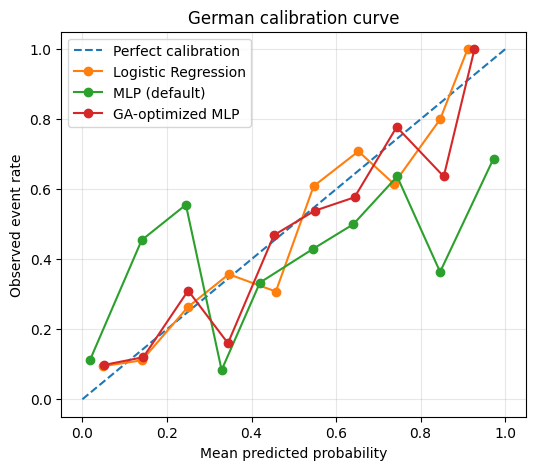

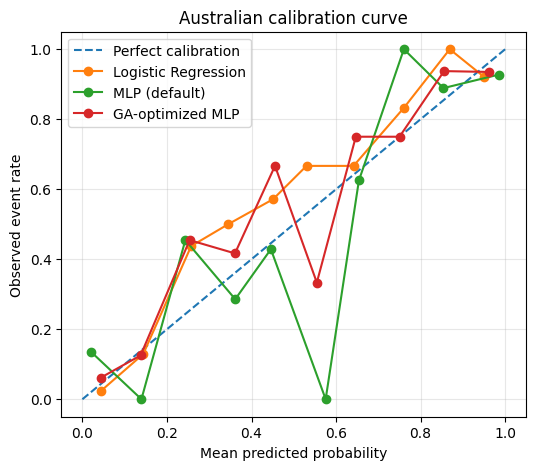

In [58]:
# Clean calibration curve plot for paper
# Keeps only Logistic Regression, Default MLP, and GA-optimized MLP.

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def plot_calibration_curves(y_true, prediction_dict, dataset_name):
    models_to_plot = [
        "Logistic Regression",
        "MLP (default)",
        "GA-optimized MLP"
    ]

    plt.figure(figsize=(6, 5))

    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

    for model_name in models_to_plot:
        y_score = prediction_dict[model_name]["y_score"]

        frac_pos, mean_pred = calibration_curve(
            y_true,
            y_score,
            n_bins=10,
            strategy="uniform"
        )

        plt.plot(
            mean_pred,
            frac_pos,
            marker="o",
            label=model_name
        )

    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed event rate")
    plt.title(f"{dataset_name} calibration curve")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


plot_calibration_curves(
    y_true=y_test,
    prediction_dict=german_final_predictions,
    dataset_name="German"
)

plot_calibration_curves(
    y_true=y_aus_test,
    prediction_dict=aus_final_predictions,
    dataset_name="Australian"
)

In [59]:
# Paper-ready final results and architecture/search summary tables

import pandas as pd
import numpy as np

def get_metric(df, dataset, model, metric):
    return df.loc[
        (df["dataset"] == dataset) & (df["model"] == model),
        metric
    ].iloc[0]

def config_to_readable_string(config):
    return (
        f"hidden={config['hidden_layer_sizes']}, "
        f"activation={config['activation']}, "
        f"alpha={config['alpha']}, "
        f"lr={config['learning_rate_init']}, "
        f"batch={config['batch_size']}"
    )

# Use existing final result, CI, and calibration tables.
paper_results_df = (
    combined_final_results_df
    .merge(
        auc_ci_df[["dataset", "model", "auc_ci_low", "auc_ci_high"]],
        on=["dataset", "model"],
        how="left"
    )
    .merge(
        calibration_df[["dataset", "model", "brier_score", "log_loss", "ece_10_bins"]],
        on=["dataset", "model"],
        how="left"
    )
)

paper_results_df = paper_results_df[
    [
        "dataset",
        "model",
        "roc_auc",
        "auc_ci_low",
        "auc_ci_high",
        "accuracy",
        "precision",
        "recall",
        "f1",
        "brier_score",
        "log_loss",
        "ece_10_bins"
    ]
].sort_values(["dataset", "roc_auc"], ascending=[True, False])

# Correct GA-only unique evals from the corrected audit table.
german_ga_unique = int(
    corrected_final_audit_df.loc[
        corrected_final_audit_df["dataset"] == "German",
        "ga_unique_evals"
    ].iloc[0]
)

aus_ga_unique = int(
    corrected_final_audit_df.loc[
        corrected_final_audit_df["dataset"] == "Australian",
        "ga_unique_evals"
    ].iloc[0]
)

german_ga_config = selected_ga_config if "selected_ga_config" in globals() else ga_best_config

architecture_summary_df = pd.DataFrame([
    {
        "dataset": "German",
        "method": "GA-selected MLP",
        "cv_rank": int(german_ga_grid_row["rank"]),
        "total_configs": len(german_grid_results_df),
        "ga_unique_evals": german_ga_unique,
        "search_pct": german_ga_unique / len(german_grid_results_df),
        "cv_auc": german_ga_grid_row["cv_roc_auc_mean"],
        "grid_best_cv_auc": german_grid_best["cv_roc_auc_mean"],
        "cv_gap_from_grid_best": german_grid_best["cv_roc_auc_mean"] - german_ga_grid_row["cv_roc_auc_mean"],
        "heldout_auc": get_metric(paper_results_df, "German", "GA-optimized MLP", "roc_auc"),
        "config": config_to_readable_string(german_ga_config)
    },
    {
        "dataset": "German",
        "method": "Grid-best MLP",
        "cv_rank": 1,
        "total_configs": len(german_grid_results_df),
        "ga_unique_evals": np.nan,
        "search_pct": np.nan,
        "cv_auc": german_grid_best["cv_roc_auc_mean"],
        "grid_best_cv_auc": german_grid_best["cv_roc_auc_mean"],
        "cv_gap_from_grid_best": 0.0,
        "heldout_auc": get_metric(paper_results_df, "German", "Grid-best MLP", "roc_auc"),
        "config": config_to_readable_string(german_grid_best_config)
    },
    {
        "dataset": "Australian",
        "method": "GA-selected MLP",
        "cv_rank": int(aus_ga_grid_row["rank"]),
        "total_configs": len(aus_grid_results_df),
        "ga_unique_evals": aus_ga_unique,
        "search_pct": aus_ga_unique / len(aus_grid_results_df),
        "cv_auc": aus_ga_grid_row["cv_roc_auc"],
        "grid_best_cv_auc": aus_grid_best["cv_roc_auc"],
        "cv_gap_from_grid_best": aus_grid_best["cv_roc_auc"] - aus_ga_grid_row["cv_roc_auc"],
        "heldout_auc": get_metric(paper_results_df, "Australian", "GA-optimized MLP", "roc_auc"),
        "config": config_to_readable_string(aus_ga_best_config)
    },
    {
        "dataset": "Australian",
        "method": "Grid-best MLP",
        "cv_rank": 1,
        "total_configs": len(aus_grid_results_df),
        "ga_unique_evals": np.nan,
        "search_pct": np.nan,
        "cv_auc": aus_grid_best["cv_roc_auc"],
        "grid_best_cv_auc": aus_grid_best["cv_roc_auc"],
        "cv_gap_from_grid_best": 0.0,
        "heldout_auc": get_metric(paper_results_df, "Australian", "Grid-best MLP", "roc_auc"),
        "config": config_to_readable_string(aus_grid_best_config)
    }
])

print("PAPER TABLE 1: FINAL HELD-OUT MODEL PERFORMANCE")
print("-" * 120)
print(paper_results_df.round(4).to_string(index=False))

print("\nPAPER TABLE 2: ARCHITECTURE SEARCH AND SELECTED CONFIGURATIONS")
print("-" * 120)
print(architecture_summary_df.round(4).to_string(index=False))

PAPER TABLE 1: FINAL HELD-OUT MODEL PERFORMANCE
------------------------------------------------------------------------------------------------------------------------
   dataset               model  roc_auc  auc_ci_low  auc_ci_high  accuracy  precision  recall     f1  brier_score  log_loss  ece_10_bins
Australian Logistic Regression   0.9315      0.8928       0.9650    0.8599     0.9135  0.8261 0.8676       0.1005    0.3321       0.0567
Australian       Grid-best MLP   0.9265      0.8864       0.9618    0.8599     0.9135  0.8261 0.8676       0.1020    0.3426       0.0504
Australian    GA-optimized MLP   0.9241      0.8833       0.9593    0.8599     0.8981  0.8435 0.8700       0.1024    0.3426       0.0460
Australian       MLP (default)   0.9020      0.8556       0.9441    0.8551     0.8972  0.8348 0.8649       0.1182    0.4738       0.0920
    German    GA-optimized MLP   0.8013      0.7456       0.8535    0.7733     0.6528  0.5222 0.5802       0.1582    0.4848       0.0586
    Germa

In [60]:
# Final notebook consistency audit

required_objects = [
    "combined_final_results_df",
    "auc_ci_df",
    "auc_diff_df",
    "calibration_df",
    "corrected_final_audit_df",
    "paper_results_df",
    "architecture_summary_df",
    "german_final_predictions",
    "aus_final_predictions",
    "german_grid_results_df",
    "aus_grid_results_df"
]

print("REQUIRED OBJECT CHECK")
print("-" * 80)

for obj in required_objects:
    print(f"{obj}: {obj in globals()}")

print("\nPOTENTIAL STALE GA SEARCH COUNTS")
print("-" * 80)
print("Correct German GA-only evals:", german_ga_unique)
print("Correct Australian GA-only evals:", aus_ga_unique)
print("German full grid size:", len(german_grid_results_df))
print("Australian full grid size:", len(aus_grid_results_df))

print("\nFINAL CLAIM CHECK")
print("-" * 80)
print("German GA vs Logistic AUC difference:",
      get_metric(paper_results_df, "German", "GA-optimized MLP", "roc_auc")
      - get_metric(paper_results_df, "German", "Logistic Regression", "roc_auc"))

print("Australian GA vs Logistic AUC difference:",
      get_metric(paper_results_df, "Australian", "GA-optimized MLP", "roc_auc")
      - get_metric(paper_results_df, "Australian", "Logistic Regression", "roc_auc"))

print("German GA vs Default MLP AUC difference:",
      get_metric(paper_results_df, "German", "GA-optimized MLP", "roc_auc")
      - get_metric(paper_results_df, "German", "MLP (default)", "roc_auc"))

print("Australian GA vs Default MLP AUC difference:",
      get_metric(paper_results_df, "Australian", "GA-optimized MLP", "roc_auc")
      - get_metric(paper_results_df, "Australian", "MLP (default)", "roc_auc"))

REQUIRED OBJECT CHECK
--------------------------------------------------------------------------------
combined_final_results_df: True
auc_ci_df: True
auc_diff_df: True
calibration_df: True
corrected_final_audit_df: True
paper_results_df: True
architecture_summary_df: True
german_final_predictions: True
aus_final_predictions: True
german_grid_results_df: True
aus_grid_results_df: True

POTENTIAL STALE GA SEARCH COUNTS
--------------------------------------------------------------------------------
Correct German GA-only evals: 64
Correct Australian GA-only evals: 40
German full grid size: 1320
Australian full grid size: 378

FINAL CLAIM CHECK
--------------------------------------------------------------------------------
German GA vs Logistic AUC difference: 0.00021164021164010727
Australian GA vs Logistic AUC difference: -0.007372400756143538
German GA vs Default MLP AUC difference: 0.010476190476190528
Australian GA vs Default MLP AUC difference: 0.022117202268431058
